# Infer plasma-cell-centered communication with CellChat

**Biology rationale.** Ligand-receptor analysis identifies inflammatory and immunosuppressive interactions associated with suboptimal hematologic response.

**Aim.** Run sample-aware CellChat analyses and compare communication pathways across treatment and response groups.

**Data input.** `./250817-AL-all78umap-singletonly-umap.rds`, `TME.noverlabel.csv`, `PC.noverlabel.csv`, `Tcell.noverlabel.csv`, `Bcell.noverlabel.csv`



**Data outputs.** `plasma_top_pathways_dotplot_%s.pdf`, `plasma_LR_partner_avg_prob_all_samples.dotplot.pdf`, `plasma_LR_partner_avg_prob_all_samples.faceted_prepost.dotplot.pdf`, `plasma_LR_partner_post_minus_pre.delta_table.csv`, `plasma_LR_partner_pre_post_delta.faceted.dotplot.pdf`

## 1. Packages and setup


In [1]:
library(Seurat)
library(patchwork)
library(speckle)
library(limma)
library(ggplot2)
library(DoubletFinder)
library(SoupX)
library(DropletUtils)
library(Matrix)
library(celda)
library(SingleCellExperiment)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t






Loading required package: SingleCellExperiment

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollaps

In [2]:
sce1<-readRDS(file='./250817-AL-all78umap-singletonly-umap.rds')

Assign the cell type annotation for each lineage to the bone marrow microenvironment cells.

In [3]:
library(tidyverse)

# --- Read ---
label1 <- readr::read_csv("TME.noverlabel.csv", show_col_types = FALSE)
label2 <- readr::read_csv("PC.noverlabel.csv", show_col_types = FALSE)
label3 <- readr::read_csv("Tcell.noverlabel.csv", show_col_types = FALSE)
label4 <- readr::read_csv("Bcell.noverlabel.csv", show_col_types = FALSE)
label5 <- readr::read_csv("Mono.noverlabel.csv", show_col_types = FALSE)
label6 <- readr::read_csv("NKcell.noverlabel.csv", show_col_types = FALSE)

# --- Helper: unify names & types ---
normalize <- function(df) {
  df %>%
    rename(
      barcode = any_of(c("barcode","Barcode")),  # handles the 'barocde' typo
      Nover   = any_of(c("Nover","Annotation","celltype","final_label","clonotype"))
    ) %>%
    mutate(
      barcode = as.character(barcode),
      # make Nover numeric; non-numeric becomes NA (prevents bind_rows() type clash)
      Nover   = as.character(Nover)
    ) %>%
    select( barcode, Nover)
}

label1 <- normalize(label1)
label2 <- normalize(label2)
label3 <- normalize(label3)
label4 <- normalize(label4)
label5 <- normalize(label5)
label6 <- normalize(label6)

# --- Build replacement lookups from label3–6 ---
lookup <- bind_rows(
  mutate(label2, .src = "Plasmacell"),
  mutate(label3, .src = "Tcell"),
  mutate(label4, .src = "Bcell"),
  mutate(label5, .src = "Mono"),
  mutate(label6, .src = "NKcell")
) %>%
  # priority order
  arrange(factor(.src, levels = c( "Plasmacell","Tcell","Bcell","Mono","NKcell"))) %>%
  group_by(barcode) %>%
  summarise(Nover_new = first(na.omit(Nover)), .groups = "drop")

# --- Replace Nover in label1 using the lookup (by barcode) ---
label1_updated <- label1 %>%
  left_join(lookup, by = "barcode") %>%
  mutate(Nover = coalesce(Nover_new, Nover)) %>%
  select(barcode, Nover)

# --- Bind label2 on it ---
final_tbl <- unique(bind_rows(label1_updated, label2))

# (optional) save
# write_csv(final_tbl, "combined_noverlabel.csv")

final_tbl


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ lubridate 1.9.4     ✔ tibble    3.3.0
✔ purrr     1.1.0     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ lubridate::%within%()    masks IRanges::%within%()
✖ dplyr::collapse()        masks IRanges::collapse()
✖ dplyr::combine()         masks Biobase::combine(), BiocGenerics::combine()
✖ dplyr::count()           masks matrixStats::count()
✖ dplyr::desc()            masks IRanges::desc()
✖ tidyr::expand()          masks Matrix::expand(), S4Vectors::expand()
✖ dplyr::filter()          masks stats::filter()
✖ dplyr::first()           masks S4Vectors::first()
✖ dplyr::lag()             masks stats::lag()
✖ tidyr::pack()            masks Matrix::pack()
✖ BiocGenerics::Position() masks ggplot2::Position(), base::Position()
✖ purrr::reduce()          masks GenomicRanges::reduce(

barcode,Nover
<chr>,<chr>
ALl14_AAACCCAGTTAAACCC-1,CD4_CM
ALl14_AAACCCATCGTCCTTG-1,Erythroid_CD34- CD71+ GlyA+
ALl14_AAACCCATCTCATTAC-1,CD14 Mono_set1High_set2High
ALl14_AAACCCATCTGTAACG-1,CD4_CM
ALl14_AAACGAAAGACCCTTA-1,CD14 Mono_set1High_set2High
ALl14_AAACGAAAGTAACCGG-1,Granulocytes (Neutrophils)
ALl14_AAACGAAAGTGATAGT-1,CD4_EM
ALl14_AAACGAACAGAAATCA-1,Colony Forming Unit-Monocytes
ALl14_AAACGAACATAGAGGC-1,CD14 Mono_set1Low_set2High


In [4]:
rownames(final_tbl)<-final_tbl$barcode
sce1@meta.data<-cbind(sce1@meta.data,final_tbl[rownames(sce1@meta.data),])

Warning message:
“Setting row names on a tibble is deprecated.”


scCustomize v2.1.2
If you find the scCustomize useful please cite.
See 'samuel-marsh.github.io/scCustomize/articles/FAQ.html' for citation info.



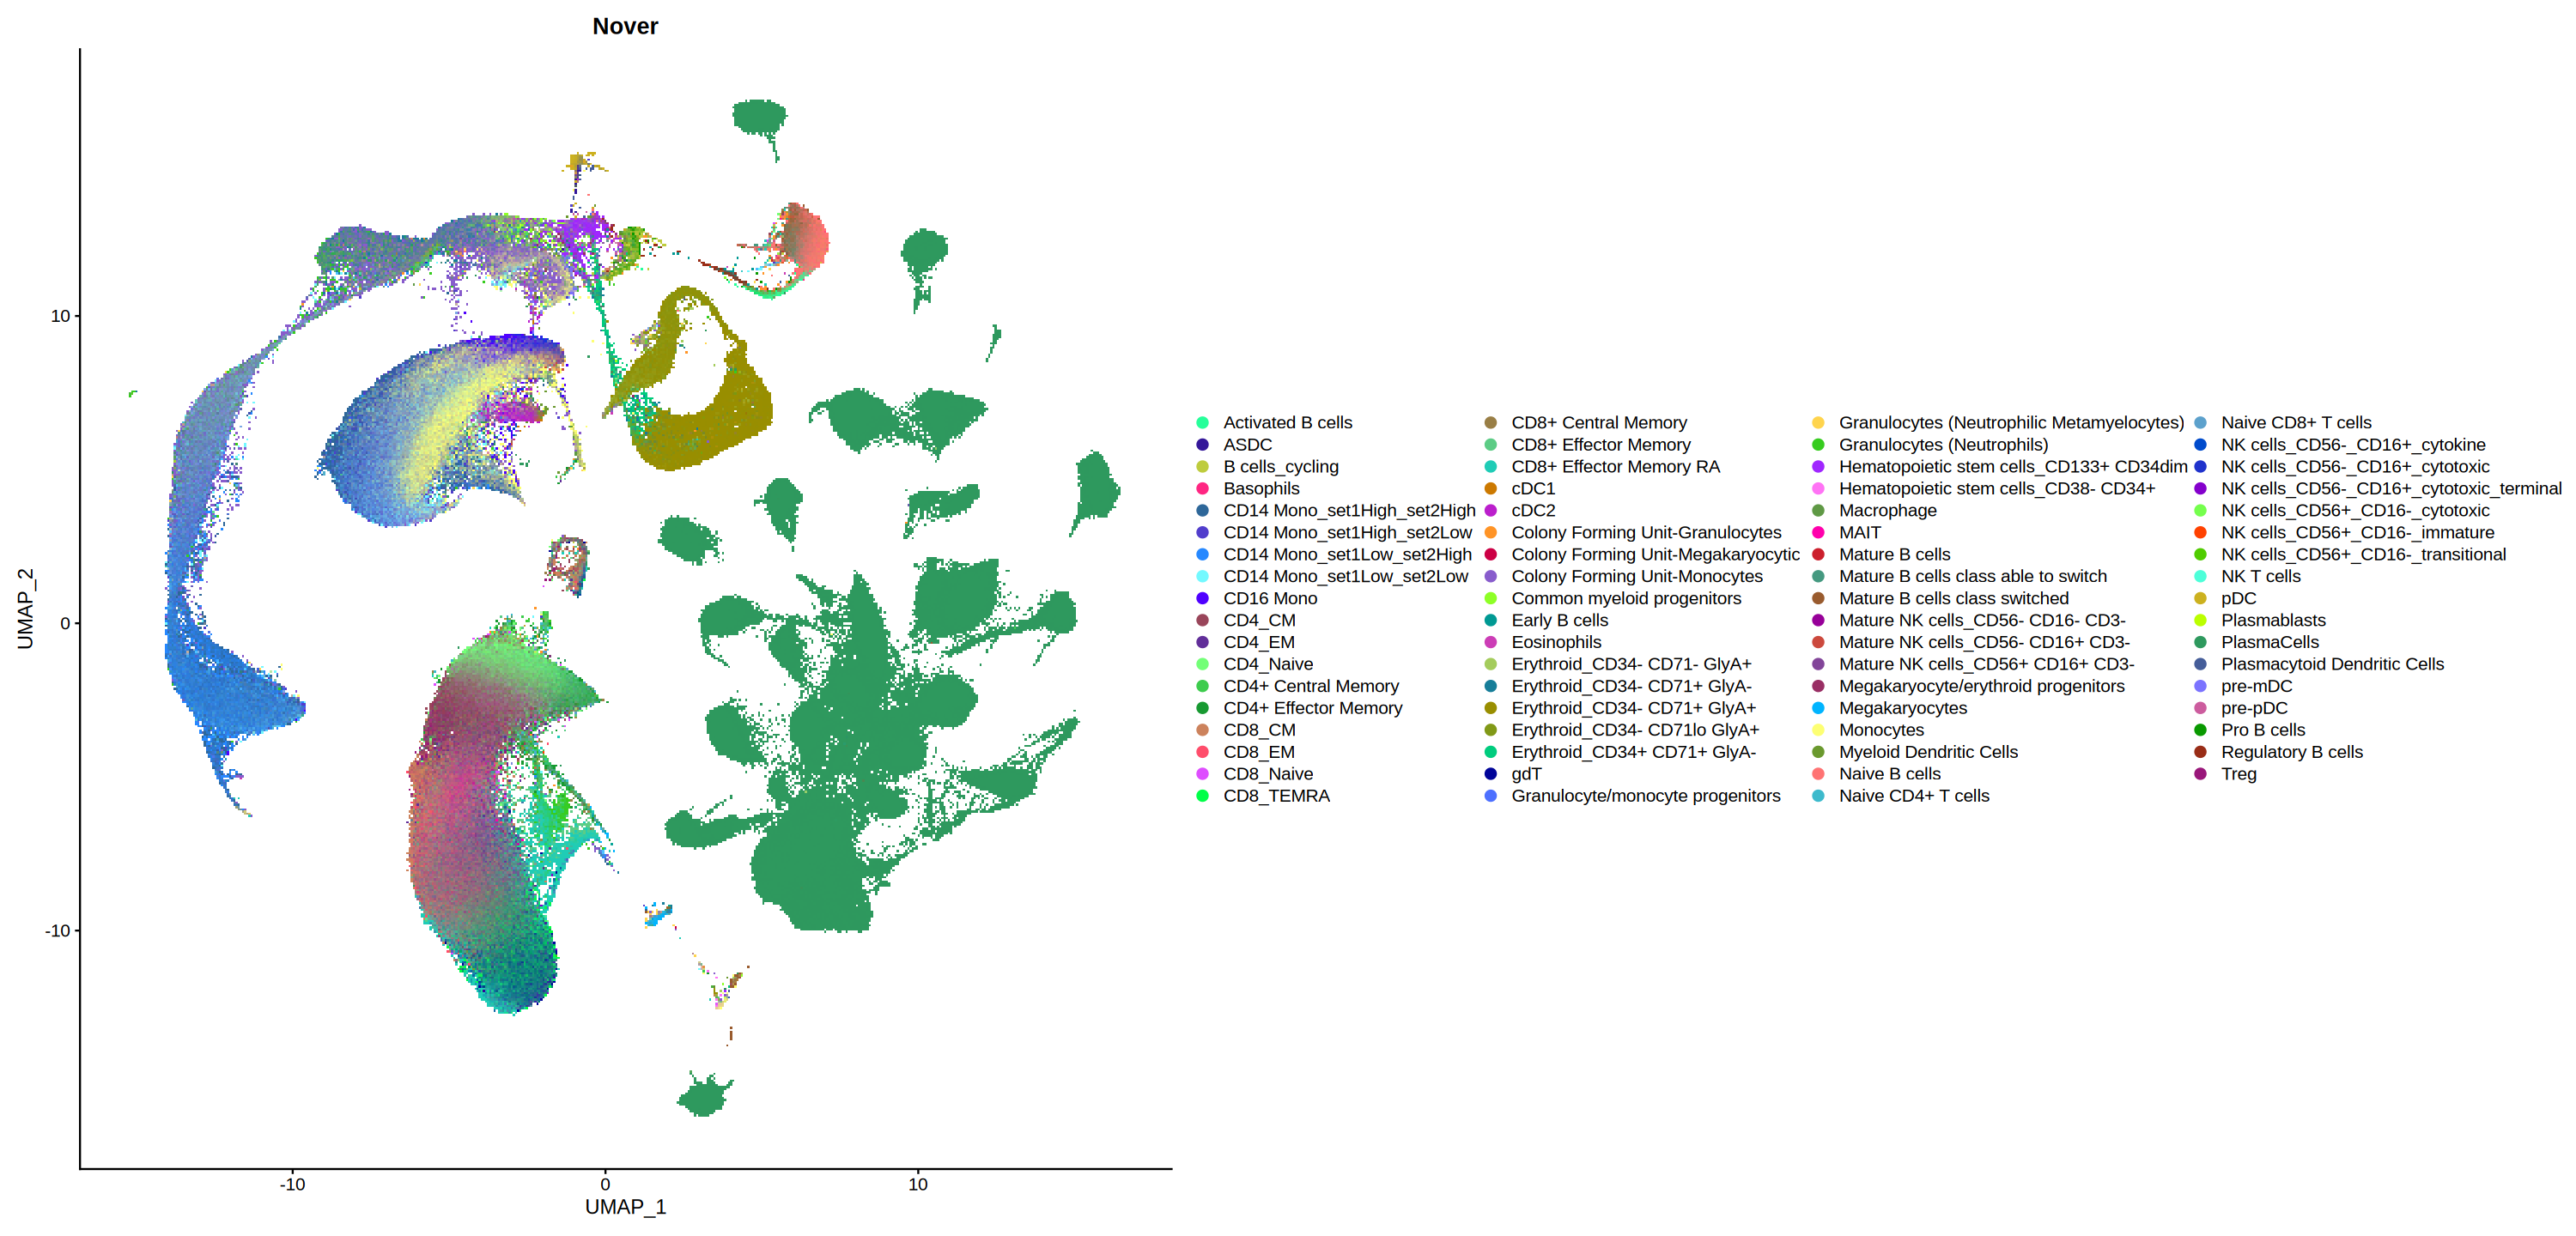

In [5]:
library(scCustomize)
options(repr.plot.height=12,repr.plot.width=25)
DimPlot_scCustom(sce1, pt.size=1,reduction = "UMAP", group.by = c("Nover"),label=F) 

## 2. Visualization and figure generation


In [4]:
cells_to_keep <- rownames(sce1@meta.data)[!grepl("plasma", sce1@meta.data$orig.ident)]
sce1 <- subset(sce1, cells = cells_to_keep)

scCustomize v2.1.2
If you find the scCustomize useful please cite.
See 'samuel-marsh.github.io/scCustomize/articles/FAQ.html' for citation info.



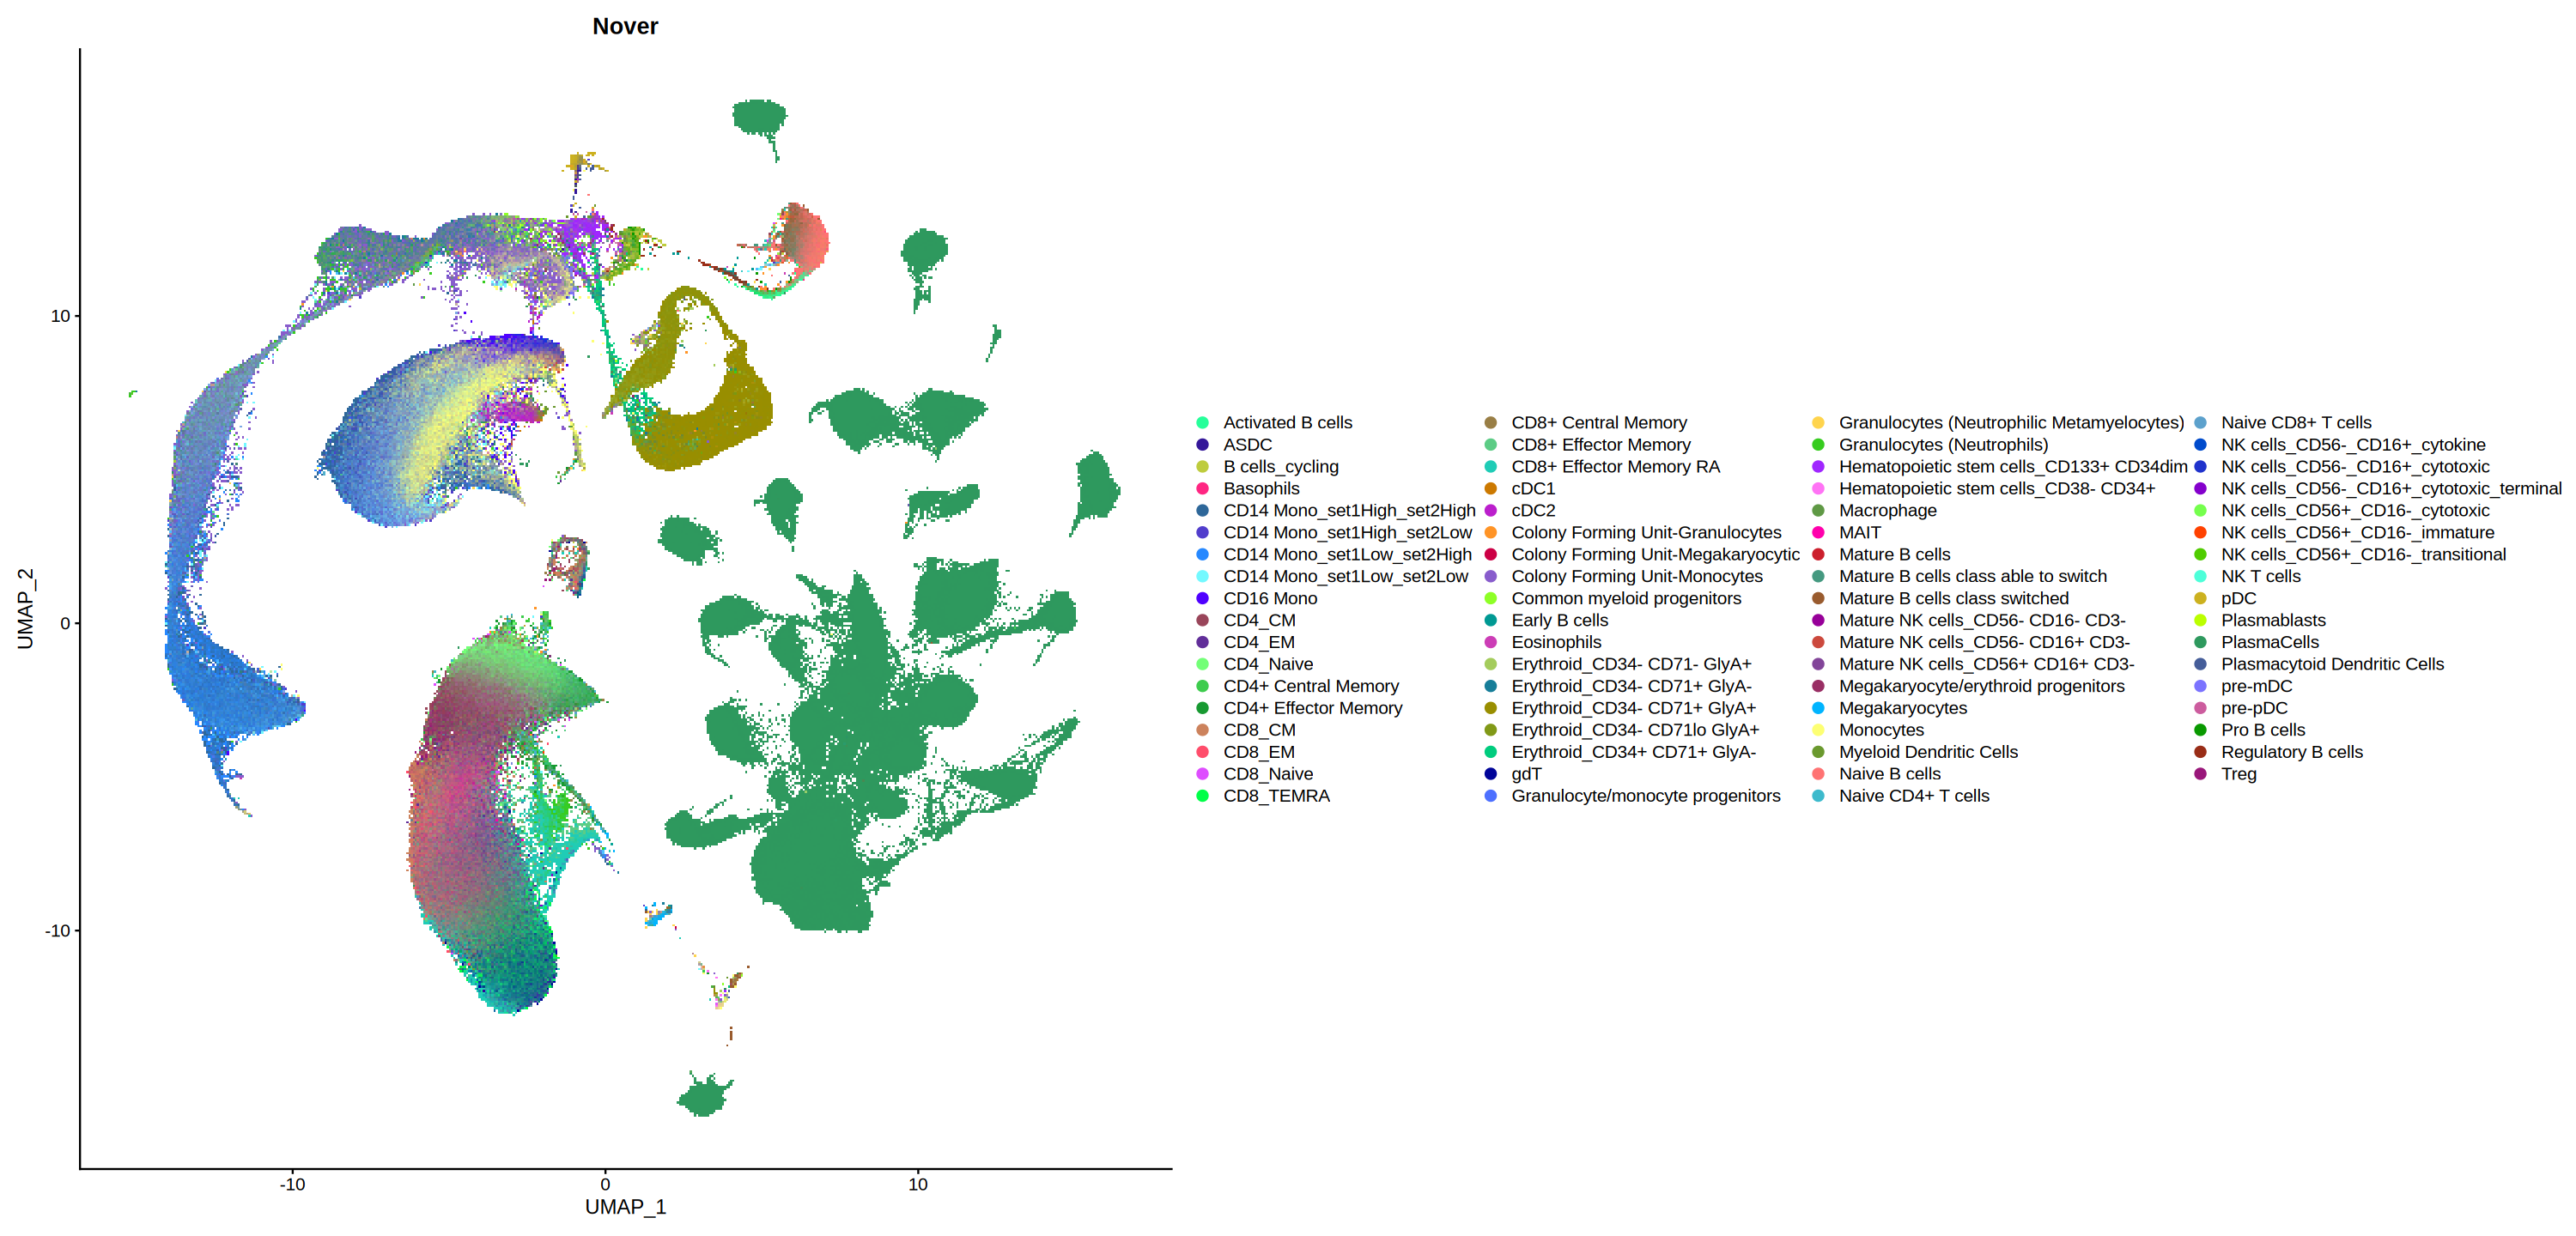

In [5]:
library(scCustomize)
options(repr.plot.height=12,repr.plot.width=25)
DimPlot_scCustom(sce1, pt.size=1,reduction = "UMAP", group.by = c("Nover"),label=F) 

In [6]:
library(ggplot2)

# Robust color extractor for a DimPlot/ggplot made by scCustomize
extract_dimplot_colors <- function(p, group_col = "ident") {
  # 1) Try to pull a discrete colour or fill scale with explicit values
  get_scale_vals <- function(p, aes_name) {
    sc <- p$scales$get_scales(aes_name)
    if (!is.null(sc)) {
      vals <- tryCatch(sc$range$range, error = function(e) NULL)
      lims <- tryCatch(sc$get_limits(), error = function(e) NULL)
      if (!is.null(vals) && length(vals) > 0) {
        # If limits missing, infer from legend/plot data levels
        if (is.null(lims) || length(lims) == 0) {
          # Try to use factor levels from p$data[[group_col]] if present
          if (!is.null(p$data[[group_col]])) {
            lims <- levels(factor(p$data[[group_col]]))
          } else {
            lims <- seq_along(vals)
          }
        }
        # If lengths differ, truncate to the shorter length safely
        n <- min(length(vals), length(lims))
        vals <- vals[seq_len(n)]
        lims <- lims[seq_len(n)]
        return(setNames(vals, lims))
      }
    }
    NULL
  }

  cols <- get_scale_vals(p, "colour")
  if (is.null(cols)) cols <- get_scale_vals(p, "color")
  if (is.null(cols)) cols <- get_scale_vals(p, "fill")

  # 2) Fallback: use rendered point colors from ggplot_build() and map back to groups
  if (is.null(cols)) {
    pb <- ggplot_build(p)
    if (length(pb$data) == 0) stop("Plot has no layer data; cannot extract colors.")
    d_layer <- pb$data[[1]]

    # Guess the grouping column used by DimPlot_scCustom
    # Seurat/DimPlot usually stores grouping in p$data$ident when group.by is a single column.
    if (is.null(p$data[[group_col]])) {
      # If 'ident' missing, try common alternatives (including your 'Nover')
      for (cand in c("ident", "group", "Nover")) {
        if (!is.null(p$data[[cand]])) { group_col <- cand; break }
      }
    }
    if (is.null(p$data[[group_col]])) {
      stop("Could not find a grouping column on the plot data (tried: ident, group, Nover).")
    }

    # Build mapping by row alignment (DimPlot preserves row order)
    df_map <- data.frame(
      group = as.character(p$data[[group_col]]),
      colour = d_layer$colour,
      stringsAsFactors = FALSE
    )

    # Keep first color per group (legend color)
    df_map <- df_map[!duplicated(df_map$group), ]
    cols <- setNames(df_map$colour, df_map$group)
  }

  cols
}


## 3. Visualization and figure generation


In [7]:
options(repr.plot.height = 12, repr.plot.width = 30)
p_umap <- DimPlot_scCustom(
  sce1, pt.size = 1, reduction = "UMAP",
  group.by = "Nover", label = FALSE
)

# Extract the exact colors used for each Nover level
cell_colors <- extract_dimplot_colors(p_umap, group_col = "ident")  # or "Nover"; the helper auto-detects

# Make sure Nover uses the same level order as the extracted colors
options(repr.plot.height = 6, repr.plot.width = 15)
cd38_expr <- FetchData(sce1, vars = c("CD38", "Nover")) %>%
  dplyr::mutate(Nover = factor(Nover, levels = names(cell_colors)))

cd38_summary <- cd38_expr %>%
  dplyr::group_by(Nover) %>%
  dplyr::summarise(mean_CD38 = mean(CD38, na.rm = TRUE), .groups = "drop")


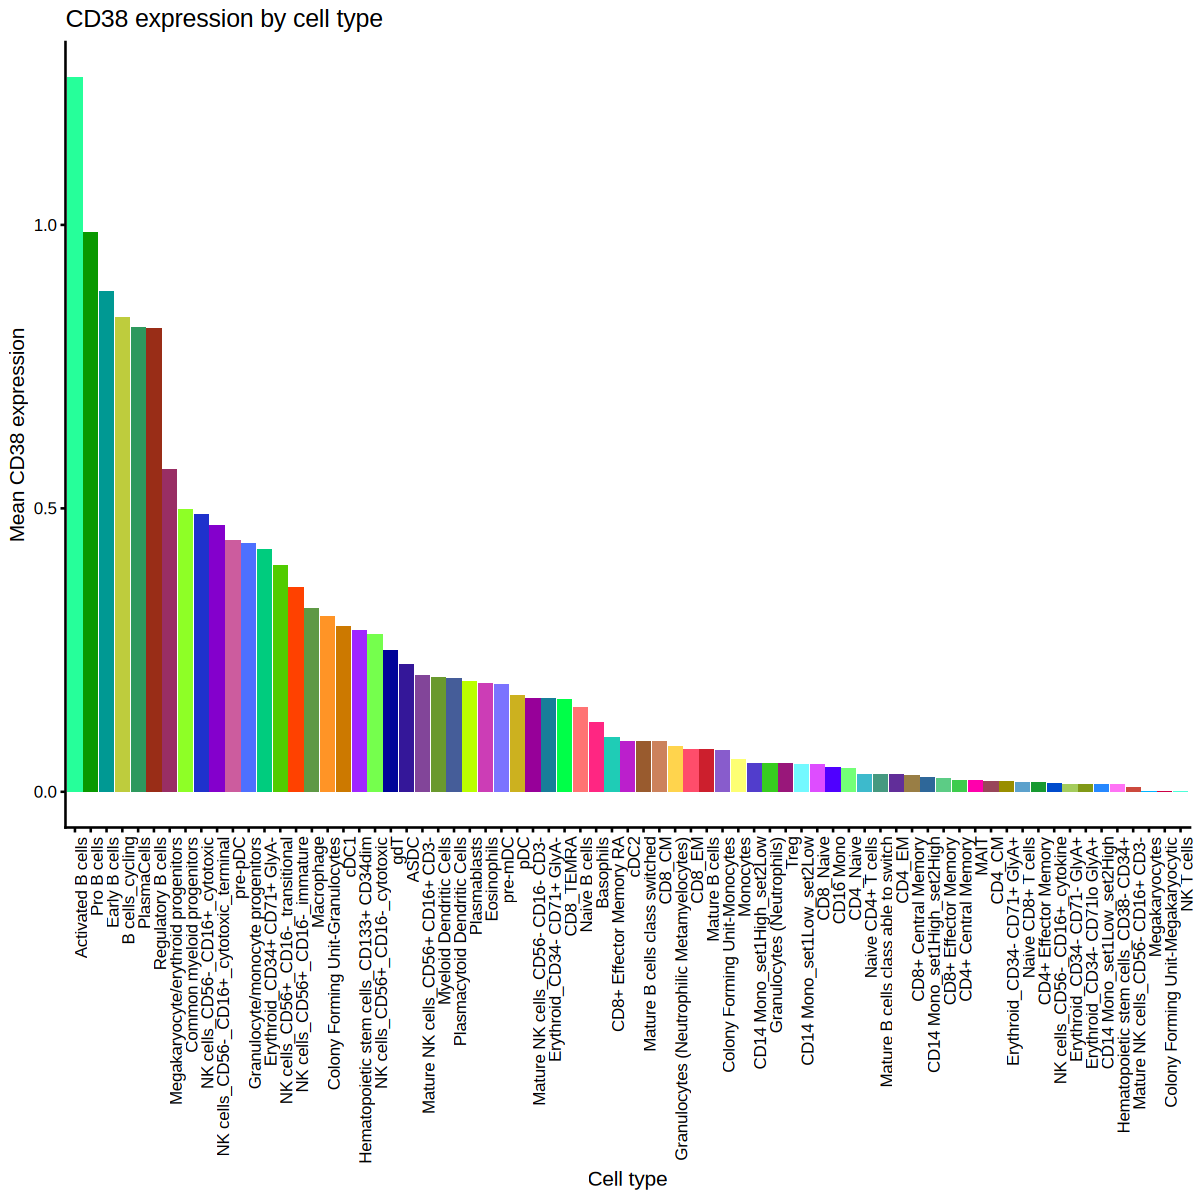

In [8]:
options(repr.plot.height=10,repr.plot.width=10)
library(dplyr)
library(ggplot2)

# Reorder by mean_CD38 (descending)
cd38_summary <- cd38_summary %>%
  mutate(Nover = reorder(Nover, -mean_CD38))

ggplot(cd38_summary, aes(x = Nover, y = mean_CD38, fill = Nover)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = cell_colors) +
  theme_classic(base_size = 12) +
  labs(x = "Cell type", y = "Mean CD38 expression",
       title = "CD38 expression by cell type") +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1),
    legend.position = "none"   # no legend
  )


In [55]:
options(repr.plot.height = 12, repr.plot.width = 30)
p_umap <- DimPlot_scCustom(
  sce1, pt.size = 1, reduction = "UMAP",
  group.by = "Nover", label = FALSE
)

# Extract the exact colors used for each Nover level
cell_colors <- extract_dimplot_colors(p_umap, group_col = "ident")  # or "Nover"; the helper auto-detects

# Make sure Nover uses the same level order as the extracted colors
options(repr.plot.height = 6, repr.plot.width = 15)
cd38_expr <- FetchData(sce1, vars = c("PTGS2", "Nover")) %>%
  dplyr::mutate(Nover = factor(Nover, levels = names(cell_colors)))

cd38_summary <- cd38_expr %>%
  dplyr::group_by(Nover) %>%
  dplyr::summarise(mean_CD38 = mean(PTGS2, na.rm = TRUE), .groups = "drop")


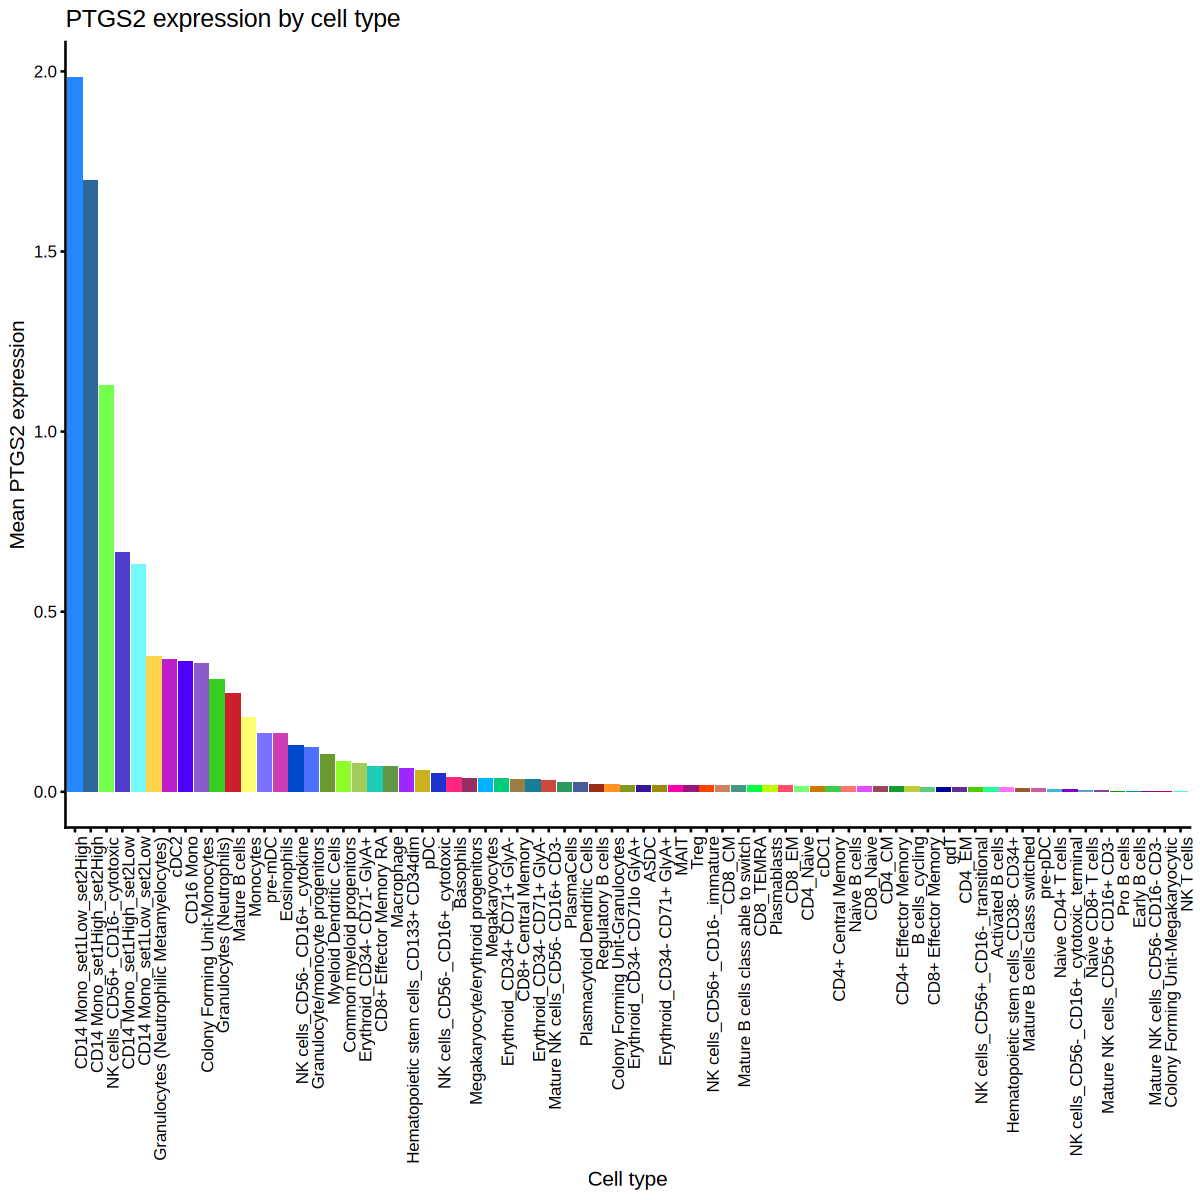

In [56]:
options(repr.plot.height=10,repr.plot.width=10)
library(dplyr)
library(ggplot2)

# Reorder by mean_CD38 (descending)
cd38_summary <- cd38_summary %>%
  mutate(Nover = reorder(Nover, -mean_CD38))

ggplot(cd38_summary, aes(x = Nover, y = mean_CD38, fill = Nover)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = cell_colors) +
  theme_classic(base_size = 12) +
  labs(x = "Cell type", y = "Mean PTGS2 expression",
       title = "PTGS2 expression by cell type") +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1),
    legend.position = "none"   # no legend
  )


In [63]:
options(repr.plot.height = 12, repr.plot.width = 30)
p_umap <- DimPlot_scCustom(
  sce1, pt.size = 1, reduction = "UMAP",
  group.by = "Nover", label = FALSE
)

# Extract the exact colors used for each Nover level
cell_colors <- extract_dimplot_colors(p_umap, group_col = "ident")  # or "Nover"; the helper auto-detects

# Make sure Nover uses the same level order as the extracted colors
options(repr.plot.height = 6, repr.plot.width = 15)
cd38_expr <- FetchData(sce1, vars = c("TNF", "Nover")) %>%
  dplyr::mutate(Nover = factor(Nover, levels = names(cell_colors)))

cd38_summary <- cd38_expr %>%
  dplyr::group_by(Nover) %>%
  dplyr::summarise(mean_CD38 = mean(TNF, na.rm = TRUE), .groups = "drop")


## 4. Visualization and figure generation


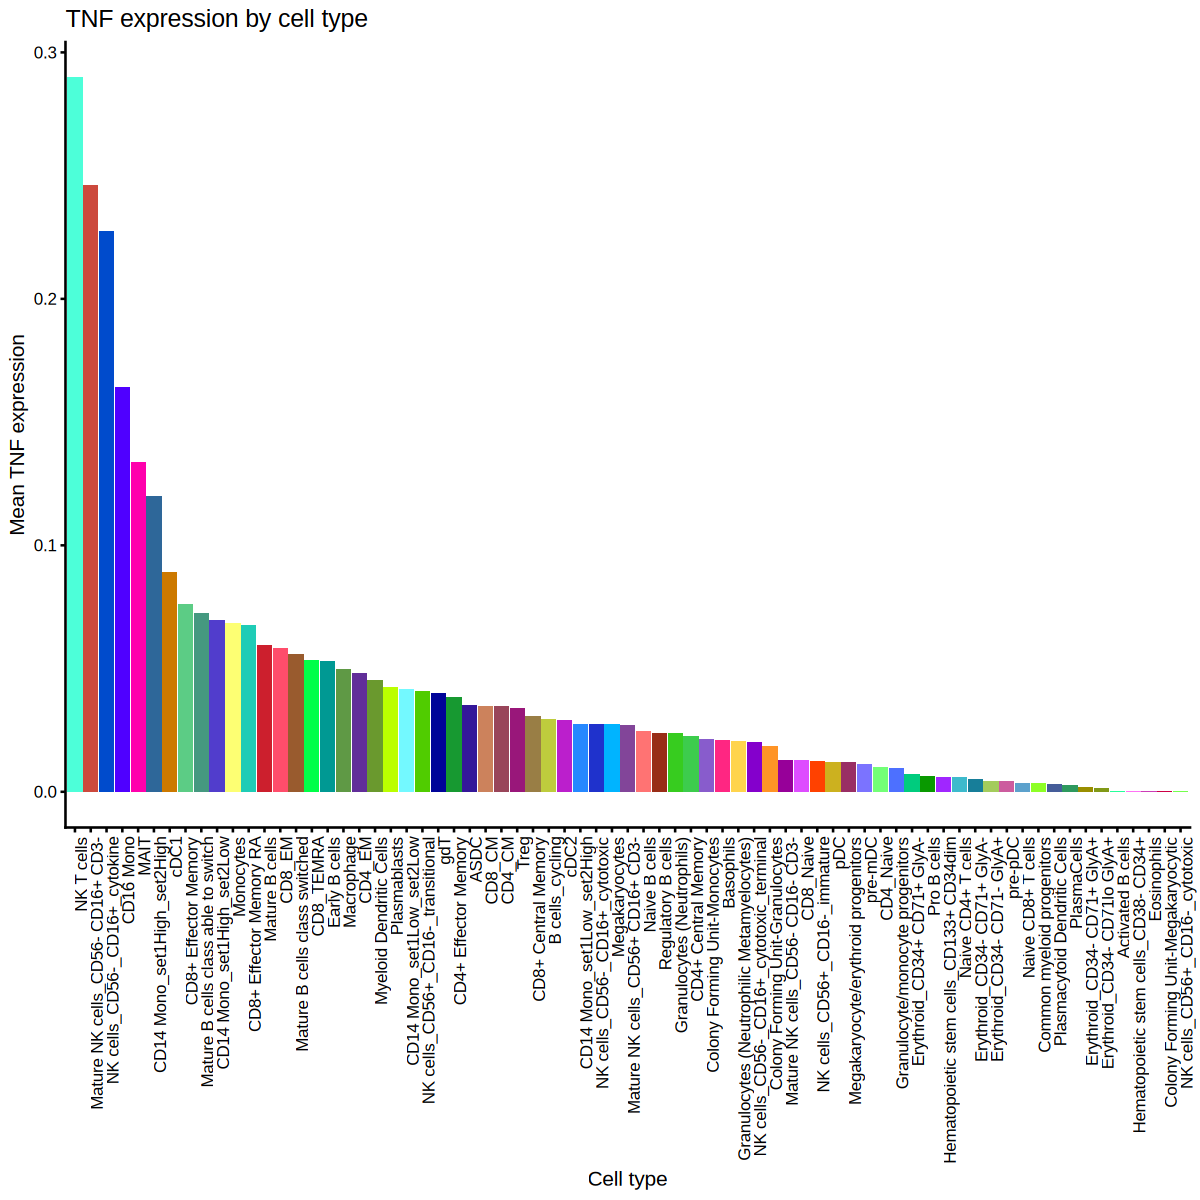

In [64]:
options(repr.plot.height=10,repr.plot.width=10)
library(dplyr)
library(ggplot2)

# Reorder by mean_CD38 (descending)
cd38_summary <- cd38_summary %>%
  mutate(Nover = reorder(Nover, -mean_CD38))

ggplot(cd38_summary, aes(x = Nover, y = mean_CD38, fill = Nover)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = cell_colors) +
  theme_classic(base_size = 12) +
  labs(x = "Cell type", y = "Mean TNF expression",
       title = "TNF expression by cell type") +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1),
    legend.position = "none"   # no legend
  )


In [65]:
options(repr.plot.height = 12, repr.plot.width = 30)
p_umap <- DimPlot_scCustom(
  sce1, pt.size = 1, reduction = "UMAP",
  group.by = "Nover", label = FALSE
)

# Extract the exact colors used for each Nover level
cell_colors <- extract_dimplot_colors(p_umap, group_col = "ident")  # or "Nover"; the helper auto-detects

# Make sure Nover uses the same level order as the extracted colors
options(repr.plot.height = 6, repr.plot.width = 15)
cd38_expr <- FetchData(sce1, vars = c("PTGER2", "Nover")) %>%
  dplyr::mutate(Nover = factor(Nover, levels = names(cell_colors)))

cd38_summary <- cd38_expr %>%
  dplyr::group_by(Nover) %>%
  dplyr::summarise(mean_CD38 = mean(PTGER2, na.rm = TRUE), .groups = "drop")


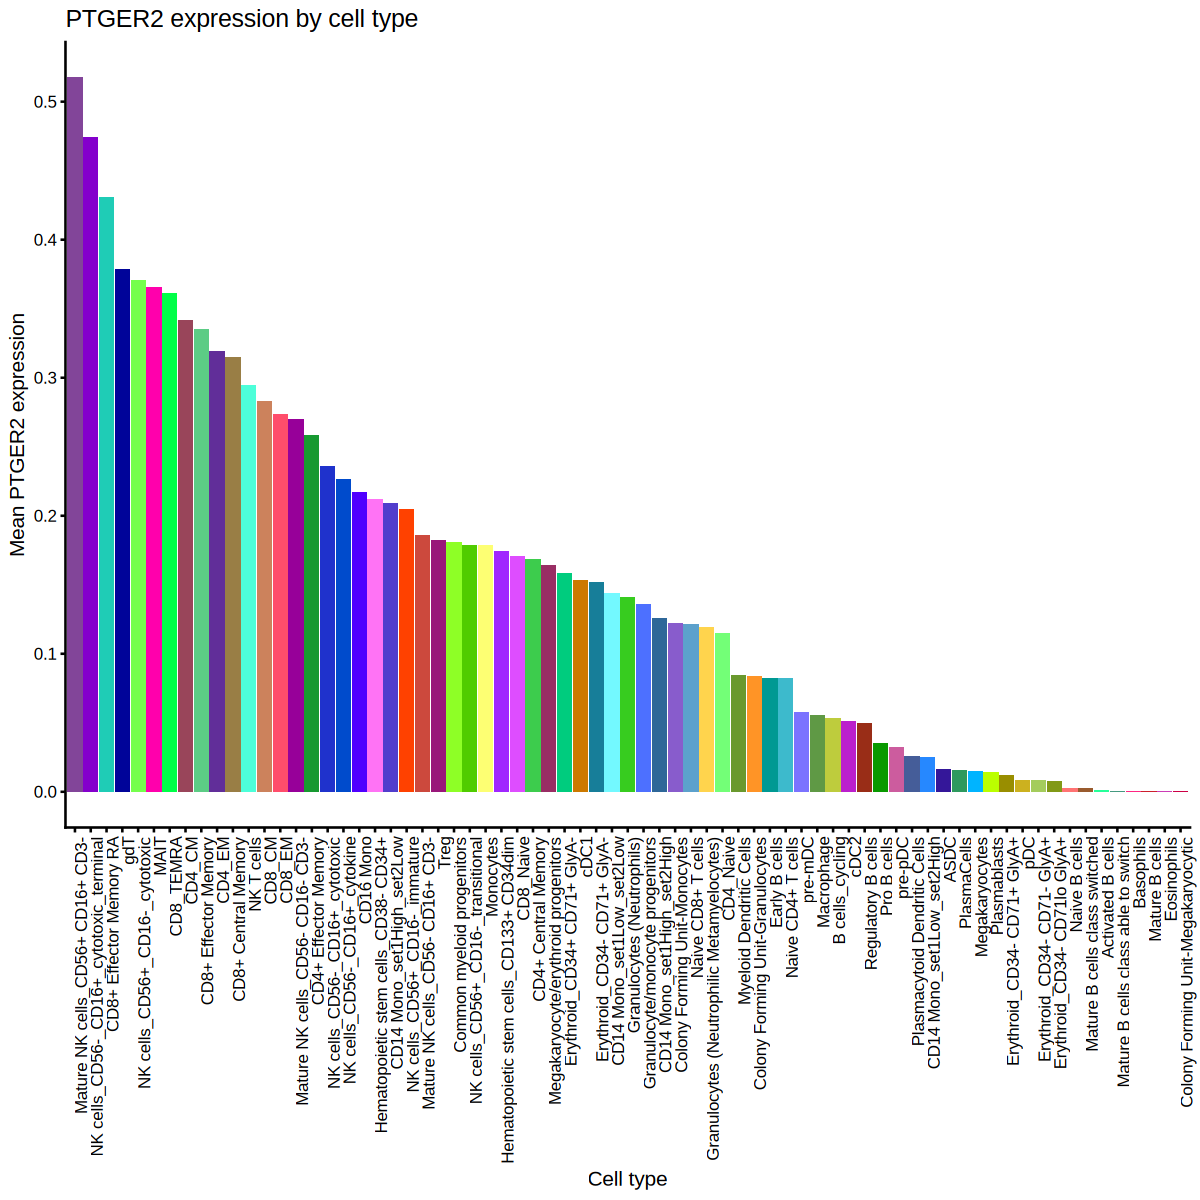

In [66]:
options(repr.plot.height=10,repr.plot.width=10)
library(dplyr)
library(ggplot2)

# Reorder by mean_CD38 (descending)
cd38_summary <- cd38_summary %>%
  mutate(Nover = reorder(Nover, -mean_CD38))

ggplot(cd38_summary, aes(x = Nover, y = mean_CD38, fill = Nover)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = cell_colors) +
  theme_classic(base_size = 12) +
  labs(x = "Cell type", y = "Mean PTGER2 expression",
       title = "PTGER2 expression by cell type") +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1),
    legend.position = "none"   # no legend
  )


## 5. Cell–cell communication analysis


In [67]:
options(repr.plot.height = 12, repr.plot.width = 30)
p_umap <- DimPlot_scCustom(
  sce1, pt.size = 1, reduction = "UMAP",
  group.by = "Nover", label = FALSE
)

# Extract the exact colors used for each Nover level
cell_colors <- extract_dimplot_colors(p_umap, group_col = "ident")  # or "Nover"; the helper auto-detects

# Make sure Nover uses the same level order as the extracted colors
options(repr.plot.height = 6, repr.plot.width = 15)
cd38_expr <- FetchData(sce1, vars = c("PTGER4", "Nover")) %>%
  dplyr::mutate(Nover = factor(Nover, levels = names(cell_colors)))

cd38_summary <- cd38_expr %>%
  dplyr::group_by(Nover) %>%
  dplyr::summarise(mean_CD38 = mean(PTGER4, na.rm = TRUE), .groups = "drop")


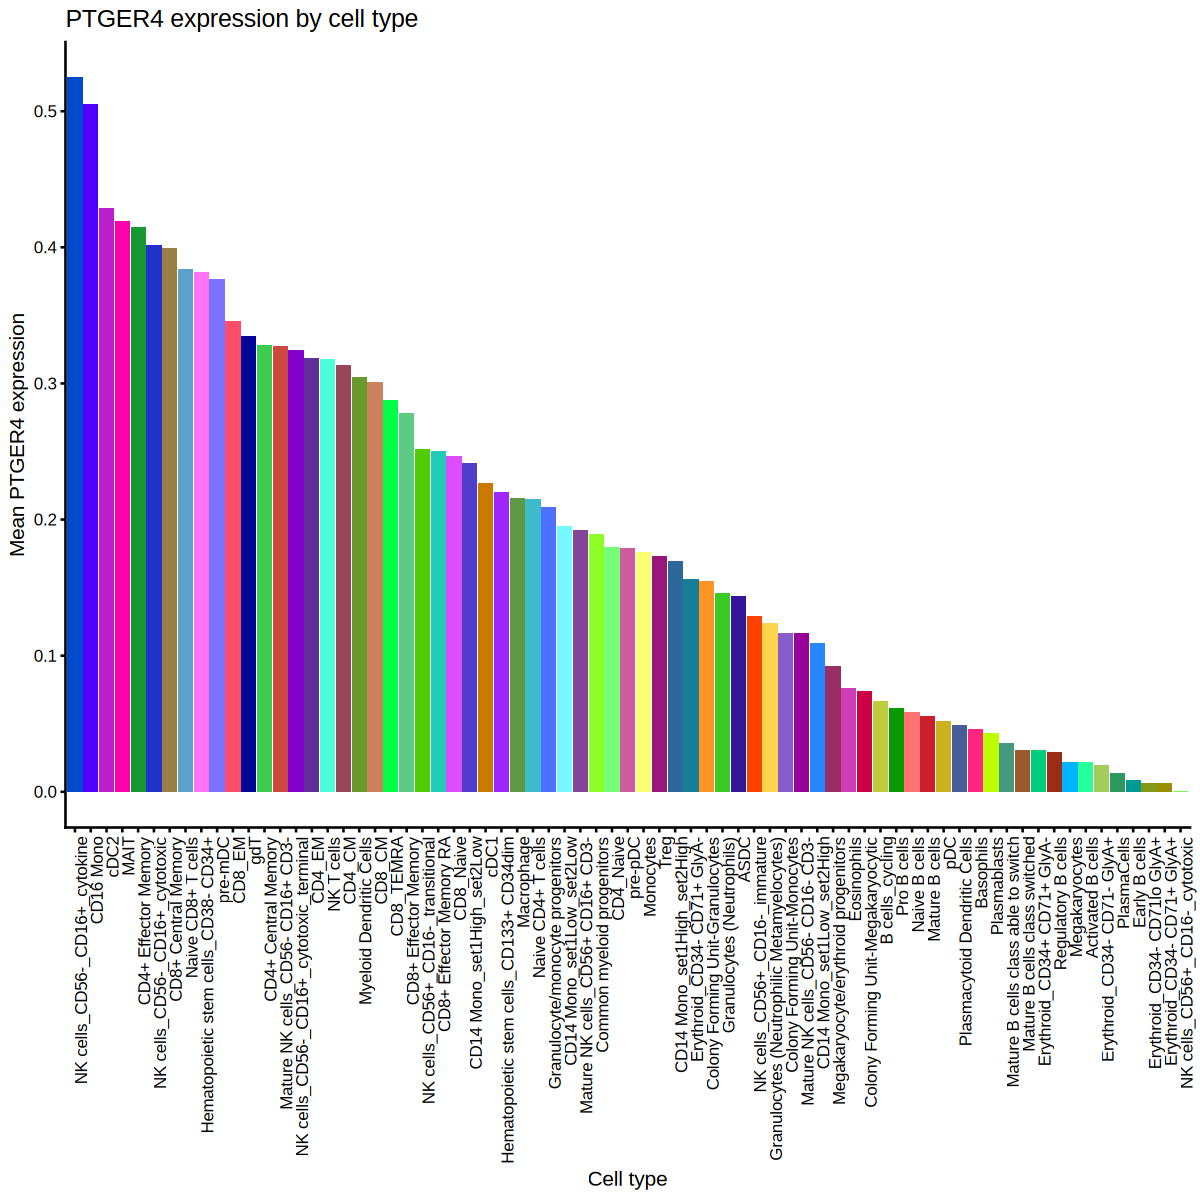

In [68]:
options(repr.plot.height=10,repr.plot.width=10)
library(dplyr)
library(ggplot2)

# Reorder by mean_CD38 (descending)
cd38_summary <- cd38_summary %>%
  mutate(Nover = reorder(Nover, -mean_CD38))

ggplot(cd38_summary, aes(x = Nover, y = mean_CD38, fill = Nover)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = cell_colors) +
  theme_classic(base_size = 12) +
  labs(x = "Cell type", y = "Mean PTGER4 expression",
       title = "PTGER4 expression by cell type") +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1),
    legend.position = "none"   # no legend
  )


In [ ]:
#### cellchat_per_sample_from_seurat.R
# Computes CellChat per sample (orig.ident), filters pathways that involve plasma cells,
# ranks by prob, and reports immune partners + LR pairs.
# -----------------------------------------------------------------------------

suppressPackageStartupMessages({
  library(Seurat)
  library(CellChat)
  library(Matrix)
  library(dplyr)
  library(tidyr)
  library(stringr)
  library(purrr)
  library(readr)
})

# ------------------------------ USER SETTINGS --------------------------------
# REQUIRED: your Seurat object (change variable name if needed)
seu <- get("sce1", envir = .GlobalEnv)   # <-- or replace "all" with your object name

# Column with cell types used as CellChat "group"
group_col   <- "Nover"             # e.g., "Nover" (or "celltype", etc.)

# Column with sample IDs to iterate over
sample_col  <- "orig.ident"

# Species for CellChat DB: "mouse" or "human"
species     <- "human"

# CellChat thresholds
expr_prop   <- 0.05     # % expressed threshold for identifyOverExpressedGenes (0-1)
min_cells   <- 10       # minimum cells per group for filterCommunication

# Optional output directory (NULL = don't write to disk)
out_dir <- "./cellchat_per_sample_plasma_trial3_repeat/"
dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)
write_outputs <- TRUE  # set FALSE if you don’t want CSVs

# Number of top pathways to keep per sample in summary (you still get full details CSV)
top_k_pathways <- 20
# -----------------------------------------------------------------------------


# ------------------------- Helper: robust compute -----------------------------
.try_compute <- function(cc) {
  ok <- TRUE
  cc2 <- tryCatch({
    computeCommunProb(cc, raw.use = TRUE, type = "truncatedMean", trim = 0.1)
  }, error = function(e) { ok <<- FALSE; e })
  if (ok) return(cc2)

  ok <- TRUE
  cc2 <- tryCatch({
    computeCommunProb(cc, raw.use = TRUE, type = "triMean")
  }, error = function(e) { ok <<- FALSE; e })
  if (ok) return(cc2)

  ok <- TRUE
  cc2 <- tryCatch({
    computeCommunProb(cc, raw.use = FALSE, type = "truncatedMean", trim = 0.1)
  }, error = function(e) { ok <<- FALSE; e })
  if (ok) return(cc2)

  stop("computeCommunProb failed under multiple settings; data may have no valid LR after filtering.")
}

# ------------------------- Helper: one-sample run -----------------------------
run_cellchat_for_subset <- function(seu_sub, group_col, species, expr_prop = 0.05, min_cells = 10) {
  # Get counts as genes x cells (CellChat expects that orientation)
  counts <- tryCatch(
    {
      # Seurat v5: use 'layer'; v4: slot="counts"
      GetAssayData(seu_sub, slot = "counts")  # works v4+ (deprecation warning in v5 is fine)
    },
    error = function(e) {
      # fallback to data slot if counts missing
      GetAssayData(seu_sub, slot = "data")
    }
  )
  if (!inherits(counts, "dgCMatrix")) counts <- as(as.matrix(counts), "dgCMatrix")

  # Build meta with "group" column (cell type)
  meta <- seu_sub@meta.data
  meta$cell  <- colnames(seu_sub)
  if (!group_col %in% colnames(meta)) {
    stop(sprintf("group_col '%s' not found in meta.data. Available: %s",
                 group_col, paste(colnames(meta), collapse = ", ")))
  }
  meta$group <- as.character(meta[[group_col]])
  rownames(meta) <- meta$cell
  meta <- meta[colnames(counts), c("cell", "group"), drop = FALSE]

  # Choose DB
  if (tolower(species) == "mouse") {
    data.cellchat <- CellChatDB.mouse
  } else {
    data.cellchat <- CellChatDB.human
  }

  # Create & subset to signaling genes
  cellchat <- createCellChat(object = counts, meta = meta, group.by = "group")
  cellchat@DB <- data.cellchat
  cellchat <- subsetData(cellchat)

  # Over-expressed genes/interactions
  expr_prop <- max(0.0, min(1.0, expr_prop))
  cellchat <- identifyOverExpressedGenes(cellchat, thresh.pc = expr_prop)
  cellchat <- identifyOverExpressedInteractions(cellchat)

  # Retry with more lenient threshold if no LR left
  if (!is.null(cellchat@LR$LRsig) && nrow(cellchat@LR$LRsig) == 0) {
    message("No LR after OE-filter; retrying with thresh.pc=0")
    cellchat <- identifyOverExpressedGenes(cellchat, thresh.pc = 0)
    cellchat <- identifyOverExpressedInteractions(cellchat)
  }

  # Compute communication probabilities
  cellchat <- .try_compute(cellchat)

  # Enforce min cells per group for robustness
  cellchat <- filterCommunication(cellchat, min.cells = min_cells)

  # Extract pairwise communication table
  df.net <- subsetCommunication(cellchat)

  # Standardize prob column name if needed
  if (!"prob" %in% colnames(df.net)) {
    if ("prob_weight" %in% colnames(df.net)) {
      df.net$prob <- df.net$prob_weight
    } else if ("weight" %in% colnames(df.net)) {
      df.net$prob <- df.net$weight
    }
  }

  df.net
}

# --------------------------- Main per-sample loop -----------------------------
all_samples <- sort(unique(seu[[sample_col]][,1]))
message(sprintf("Found %d samples via %s", length(all_samples), sample_col))

results_list <- list()

for (sid in all_samples) {
  message(sprintf(">>> Processing sample: %s", sid))
  seu_sub <- subset(seu, subset = !!as.name(sample_col) == sid)

  # Quick guard: require at least two groups and enough cells
  tab_groups <- table(seu_sub@meta.data[[group_col]])
  if (length(tab_groups) < 2) {
    message(sprintf("Skipping %s: <2 groups in '%s'", sid, group_col))
    next
  }

  df.net <- tryCatch(
    run_cellchat_for_subset(seu_sub, group_col, species, expr_prop, min_cells),
    error = function(e) {
      message(sprintf("CellChat failed for %s: %s", sid, e$message))
      NULL
    }
  )
  if (is.null(df.net) || nrow(df.net) == 0) {
    message(sprintf("No interactions for %s after filtering.", sid))
    next
  }

  df.net$sample_id <- sid
  results_list[[sid]] <- df.net

  # Optional: write raw interactions per-sample
  if (write_outputs) {
    write_csv(df.net, file.path(out_dir, sprintf("cellchat_pairs_%s.csv", sid)))
  }
}

if (length(results_list) == 0) {
  stop("No samples produced interactions. Check thresholds, group_col, or data sparsity.")
}

all_pairs <- bind_rows(results_list)



In [10]:
# Ensure stringr is loaded
suppressPackageStartupMessages(library(stringr))

# ---------------- Mark plasma rows ON all_pairs, then filter -----------------

# How we detect "plasma cell" labels in your metadata
plasma_patterns <- c( "PlasmaCells")
plasma_regex    <- paste0("(^|[^A-Za-z])(", paste(plasma_patterns, collapse="|"), ")([^A-Za-z]|$)")


all_pairs <- all_pairs %>%
  mutate(
    is_plasma_source = str_detect(source, plasma_regex),
    is_plasma_target = str_detect(target, plasma_regex)
  )

plasma_pairs <- all_pairs %>%
  filter(is_plasma_source | is_plasma_target) %>%
  mutate(
    direction = case_when(
      is_plasma_source & !is_plasma_target ~ "Plasma->Immune",
      !is_plasma_source & is_plasma_target ~ "Immune->Plasma",
      TRUE ~ "Plasma<->Plasma"
    ),
    partner_cell = if_else(is_plasma_source, target, source)
  )

if (nrow(plasma_pairs) == 0) {
  warning("No plasma-involving interactions detected with current plasma_patterns.")
}

# -------------------------- Pathway name fallback ----------------------------
if (!"pathway_name" %in% colnames(plasma_pairs)) {
  plasma_pairs <- plasma_pairs %>%
    mutate(
      pathway_name = dplyr::coalesce(.data$pathway_name, .data$interaction_name_2)
    )
}

# -------------------------- Rank pathways per sample -------------------------
ranked_summary <- plasma_pairs %>%
  group_by(sample_id, pathway_name) %>%
  summarise(
    max_prob = max(prob, na.rm = TRUE),
    mean_prob = mean(prob, na.rm = TRUE),
    n_pairs = dplyr::n(),
    partners = paste(sort(unique(partner_cell)), collapse = "; "),
    directions = paste(sort(unique(direction)), collapse = "; "),
    .groups = "drop"
  ) %>%
  arrange(sample_id, desc(max_prob)) %>%
  group_by(sample_id) %>%
  mutate(rank = dplyr::row_number()) %>%
  ungroup() %>%
  filter(rank <= top_k_pathways)

# Detailed LR rows for those top pathways
top_keys <- ranked_summary %>% distinct(sample_id, pathway_name)
details_top <- plasma_pairs %>%
  inner_join(top_keys, by = c("sample_id", "pathway_name")) %>%
  select(sample_id, pathway_name, direction, source, target,
         partner_cell, ligand, receptor, interaction_name_2, prob) %>%
  arrange(sample_id, desc(prob))

# ------------------------------ Write outputs --------------------------------
if (isTRUE(write_outputs)) {
  readr::write_csv(ranked_summary, file.path(out_dir, "plasma_pathways_ranked_summary.csv"))
  readr::write_csv(details_top,   file.path(out_dir, "plasma_pathways_top_details.csv"))
  readr::write_csv(plasma_pairs,  file.path(out_dir, "plasma_pathways_all_pairs.csv"))
}

# ------------------------------ Quick console peek ---------------------------
message("# ---- Top plasma-involving pathways per sample (head) ----")
print(ranked_summary %>% group_by(sample_id) %>% slice_head(n = 10) %>% ungroup())

message("# ---- Example detail rows (head) ----")
print(details_top %>% group_by(sample_id) %>% slice_head(n = 10) %>% ungroup())


# ---- Top plasma-involving pathways per sample (head) ----



# A tibble: 766 × 8
   sample_id pathway_name  max_prob  mean_prob n_pairs partners directions  rank
   <chr>     <chr>            <dbl>      <dbl>   <int> <chr>    <chr>      <int>
 1 ALk1post  MIF          0.000593  0.000126        83 CD14 Mo… Immune->P…     1
 2 ALk1post  APP          0.000372  0.0000499       20 CD14 Mo… Immune->P…     2
 3 ALk1post  MHC-I        0.000316  0.0000392      170 CD14 Mo… Immune->P…     3
 4 ALk1post  CypA         0.000183  0.0000940       16 cDC2; C… Immune->P…     4
 5 ALk1post  BAFF         0.0000631 0.0000100       70 CD14 Mo… Immune->P…     5
 6 ALk1post  PECAM2       0.0000578 0.00000719      39 CD14 Mo… Immune->P…     6
 7 ALk1post  CD99         0.0000546 0.0000172       58 CD14 Mo… Immune->P…     7
 8 ALk1post  CLEC         0.0000357 0.00000996      18 CD4_CM;… Plasma->I…     8
 9 ALk1post  APRIL        0.0000330 0.00000610      30 CD14 Mo… Immune->P…     9
10 ALk1post  GALECTIN     0.0000330 0.0000120       29 CD14 Mo… Immune->P…    10
# ℹ 756 

# ---- Example detail rows (head) ----



# A tibble: 769 × 10
   sample_id pathway_name direction   source target partner_cell ligand receptor
   <chr>     <chr>        <chr>       <fct>  <fct>  <fct>        <chr>  <chr>   
 1 ALk1post  MIF          Plasma->Im… Plasm… pre-m… pre-mDC      MIF    CD74_CD…
 2 ALk1post  MIF          Plasma->Im… Plasm… pre-m… pre-mDC      MIF    CD74_CX…
 3 ALk1post  MIF          Immune->Pl… Eryth… Plasm… Erythroid_C… MIF    CD74_CX…
 4 ALk1post  MIF          Plasma->Im… Plasm… Myelo… Myeloid Den… MIF    CD74_CX…
 5 ALk1post  MIF          Plasma->Im… Plasm… cDC2   cDC2         MIF    CD74_CD…
 6 ALk1post  MIF          Immune->Pl… Myelo… Plasm… Myeloid Den… MIF    CD74_CX…
 7 ALk1post  MIF          Plasma->Im… Plasm… pre-p… pre-pDC      MIF    CD74_CX…
 8 ALk1post  MIF          Plasma->Im… Plasm… Myelo… Myeloid Den… MIF    CD74_CD…
 9 ALk1post  APP          Immune->Pl… pDC    Plasm… pDC          APP    CD74    
10 ALk1post  MIF          Immune->Pl… Eryth… Plasm… Erythroid_C… MIF    CD74_CD…
# ℹ 759

In [12]:
# ===================== Plasma-Interaction Dotplot (Fixed + Filter) =====================
# - Works with objects created earlier: `ranked_summary`, `details_top`
# - One PDF per sample: y = ligand–receptor (grouped by pathway), x = immune partner
# - Point size = CellChat probability (prob); color = direction
# - FIXES:
#     * ggplot2 3.4+: element_line(size=) -> element_line(linewidth=)
#     * UTF-8 label warnings: sanitize to ASCII by default; optional cairo device
# - NEW:
#     * partner_filter_keywords / partner_filter_exclude to restrict x-axis cell types
# ==============================================================================

suppressPackageStartupMessages({
  library(dplyr)
  library(stringr)
  library(tidyr)
  library(ggplot2)
  library(forcats)
  library(readr)
})

# ------------------------------- User Options ---------------------------------
OUT_DIR_PLOTS   <- "./cellchat_per_sample_plasma_trial3_repeat/plots_dotplot/"
dir.create(OUT_DIR_PLOTS, showWarnings = FALSE, recursive = TRUE)

top_k_pathways  <- 20          # keep top-K pathways per sample (should match build of details_top)
min_prob_show   <- 0           # drop tiny edges if desired (e.g., 0.01)
point_alpha     <- 0.95
size_range      <- c(1.8, 8.5)

# Fix the order of immune partners on x; if NULL, order by total prob descending
fixed_immune_order <- NULL   # e.g., c("CD4T","CD8T","NK","Mature B","CD14+ Monocyte","DC")

# --- NEW: Filter immune partners by keywords/regex (case-insensitive) ---
# Examples:
# partner_filter_keywords <- c("^CD8", "Monocyte", "NK")
# partner_filter_exclude  <- c("B cell|Mature B")  # optional blacklist; patterns combined with OR
partner_filter_keywords <- c("PlasmaCells",unique(label3$Nover),unique(label4$Nover),unique(label5$Nover),unique(label6$Nover))
partner_filter_exclude  <- NULL
# --- Unicode handling ---
# If TRUE and Cairo is installed, save with a Unicode-capable device and keep Unicode punctuation
use_cairo_unicode <- FALSE    # set TRUE to keep “–” and “•” etc. (requires Cairo)

# If FALSE (default), labels are sanitized to ASCII to avoid device font warnings
keep_unicode_labels <- use_cairo_unicode

# ------------------------------ Safety Checks ---------------------------------
if (!exists("ranked_summary") || !exists("details_top")) {
  stop("Objects `ranked_summary` and `details_top` must exist in the session.")
}

df_sum <- ranked_summary
df_det <- details_top

# ------------------------------- Helpers --------------------------------------
sanitize_ascii <- function(x) {
  # Replace common UTF-8 punctuation first, then transliterate to ASCII
  x <- gsub("–", "-", x, fixed = TRUE)   # en dash -> hyphen
  x <- gsub("—", "-", x, fixed = TRUE)   # em dash -> hyphen
  x <- gsub("•", "-", x, fixed = TRUE)   # bullet -> hyphen
  x <- gsub("·", "-", x, fixed = TRUE)   # middle dot -> hyphen
  iconv(x, from = "", to = "ASCII//TRANSLIT")
}

lab_safe <- function(x) if (keep_unicode_labels) x else sanitize_ascii(x)

lr_with_pathway <- function(pathway, lr) sprintf("[%s] %s", pathway, lr)

# NEW: assemble combined OR-regex from vector of patterns (NULL-safe)
assembled_regex <- function(x) {
  if (is.null(x) || length(x) == 0) return(NULL)
  paste0("(", paste(x, collapse = "|"), ")")
}

# -------------------------------- Plotter -------------------------------------
plot_plasma_dotplot_for_sample <- function(sid, df_sum, df_det) {
  # Keep top pathways (already top-k in ranked_summary; enforce again)
  top_paths <- df_sum %>%
    filter(sample_id == sid) %>%
    arrange(desc(max_prob)) %>%
    slice_head(n = top_k_pathways) %>%
    pull(pathway_name) %>%
    unique()

  # LR details within those pathways
  pdat <- df_det %>%
    filter(sample_id == sid, pathway_name %in% top_paths) %>%
    filter(!is.na(prob), prob >= min_prob_show) %>%
    mutate(
      lr_label  = lr_with_pathway(pathway_name, interaction_name_2),
      direction = factor(direction, levels = c("Plasma->Immune","Immune->Plasma","Plasma<->Plasma"))
    )

  if (nrow(pdat) == 0) {
    message(sprintf("No rows to plot for sample %s", sid))
    return(NULL)
  }

  # --- NEW: optional restriction of immune partners by keyword/regex ---
  rx_include <- assembled_regex(partner_filter_keywords)
  rx_exclude <- assembled_regex(partner_filter_exclude)

  if (!is.null(rx_include)) {
    pdat <- pdat %>%
      filter(str_detect(partner_cell, regex(rx_include, ignore_case = TRUE)))
  }
  if (!is.null(rx_exclude)) {
    pdat <- pdat %>%
      filter(!str_detect(partner_cell, regex(rx_exclude, ignore_case = TRUE)))
  }

  if (nrow(pdat) == 0) {
    message(sprintf("No rows to plot for sample %s after partner filter.", sid))
    return(NULL)
  }

  # X order (immune partners)
  if (is.null(fixed_immune_order)) {
    immune_order <- pdat %>%
      count(partner_cell, wt = prob) %>%
      arrange(desc(n)) %>%
      pull(partner_cell)
  } else {
    immune_order <- fixed_immune_order
  }

  # Y order: group by pathway, then by decreasing prob
  lr_order <- pdat %>%
    group_by(pathway_name, lr_label) %>%
    summarise(max_prob = max(prob, na.rm = TRUE), .groups = "drop") %>%
    arrange(fct_reorder(pathway_name, -max_prob, .fun = max), desc(max_prob), lr_label) %>%
    pull(lr_label)

  pdat <- pdat %>%
    mutate(
      partner_cell = factor(partner_cell, levels = immune_order),
      lr_label     = factor(lr_label,     levels = rev(unique(lr_order))) # top at top
    )

  # Light banding by pathway (optional): compute y spans for geom_rect
  band_df <- pdat %>%
    distinct(lr_label, pathway_name) %>%
    arrange(lr_label) %>%
    group_by(pathway_name) %>%
    summarise(
      ymin = which(levels(pdat$lr_label) %in% lr_label) |> min() - 0.5,
      ymax = which(levels(pdat$lr_label) %in% lr_label) |> max() + 0.5,
      .groups = "drop"
    ) %>%
    mutate(
      band_id = as.integer(fct_inorder(pathway_name)),
      fill = ifelse(band_id %% 2 == 1, "bandA", "bandB")
    )

  # Build plot
  g <- ggplot() +
    # pathway bands
    geom_rect(
      data = band_df,
      aes(xmin = 0.5, xmax = length(levels(pdat$partner_cell)) + 0.5,
          ymin = ymin, ymax = ymax, fill = fill),
      alpha = 0.15, inherit.aes = FALSE
    ) +
    scale_fill_manual(values = c(bandA = "skyblue", bandB = "mistyrose"), guide = "none") +

    # dots (size=prob, color by direction)
    geom_point(
      data = pdat,
      aes(x = partner_cell, y = lr_label, size = prob, color = direction),
      alpha = point_alpha
    ) +
    scale_size(range = size_range, name = "Interaction probability") +
    scale_color_manual(values = c("Plasma->Immune" = "#6A1B9A",
                                  "Immune->Plasma" = "#1565C0",
                                  "Plasma<->Plasma" = "#8D6E63"),
                       name = "Direction") +

    labs(
      x = lab_safe("Immune partner cell type"),
      y = lab_safe("Ligand–Receptor (grouped by pathway)"),
      title = lab_safe(sprintf("Plasma-involving top pathways • Sample: %s", sid)),
      subtitle = lab_safe("Dot size: CellChat probability (prob). Color: direction.")
    ) +
    theme_minimal(base_size = 11) +
    theme(
      panel.grid.major.x = element_line(linewidth = 0.2),  # <-- linewidth (fixed)
      panel.grid.major.y = element_line(linewidth = 0.2),
      axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1),
      plot.title = element_text(face = "bold"),
      plot.margin = margin(5.5, 80, 5.5, 5.5, "pt")        # room for right annotations
    )

  # Right-margin pathway labels
  ann_df <- band_df %>%
    mutate(y = (ymin + ymax)/2, x = length(levels(pdat$partner_cell)) + 0.95)

  g <- g +
    geom_text(data = ann_df,
              aes(x = x, y = y, label = lab_safe(pathway_name)),
              hjust = 0, size = 3, fontface = "bold", inherit.aes = FALSE) +
    coord_cartesian(clip = "off")

  g
}

# --------------------------------- Render -------------------------------------
samples <- sort(unique(df_det$sample_id))

if (use_cairo_unicode) {
  if (!requireNamespace("Cairo", quietly = TRUE)) {
    warning("Cairo not installed; falling back to ggsave() with ASCII-sanitized labels.")
    keep_unicode_labels <- FALSE
    for (sid in samples) {
      gp <- plot_plasma_dotplot_for_sample(sid, df_sum, df_det)
      if (is.null(gp)) next
      out_path <- file.path(OUT_DIR_PLOTS, sprintf("plasma_top_pathways_dotplot_%s.pdf", sid))
      ggsave(out_path, gp, width = 8.5, height = 11, limitsize = FALSE)
      message(sprintf("Saved: %s", out_path))
    }
  } else {
    # Unicode-capable PDF (keeps “–” and “•”)
    keep_unicode_labels <- TRUE
    for (sid in samples) {
      gp <- plot_plasma_dotplot_for_sample(sid, df_sum, df_det)
      if (is.null(gp)) next
      out_path <- file.path(OUT_DIR_PLOTS, sprintf("plasma_top_pathways_dotplot_%s.pdf", sid))
      Cairo::CairoPDF(out_path, width = 8.5, height = 11, family = "DejaVu Sans")
      print(gp)
      dev.off()
      message(sprintf("Saved: %s", out_path))
    }
  }
} else {
  # ASCII-safe default (no font/device warnings)
  keep_unicode_labels <- FALSE
  for (sid in samples) {
    gp <- plot_plasma_dotplot_for_sample(sid, df_sum, df_det)
    if (is.null(gp)) next
    out_path <- file.path(OUT_DIR_PLOTS, sprintf("plasma_top_pathways_dotplot_%s.pdf", sid))
    ggsave(out_path, gp, width = 8.5, height = 11, limitsize = FALSE)
    message(sprintf("Saved: %s", out_path))
  }
}

# ---------------------------------- Done --------------------------------------


Saved: ./cellchat_per_sample_plasma_trial3_repeat/plots_dotplot//plasma_top_pathways_dotplot_ALk1post.pdf

Saved: ./cellchat_per_sample_plasma_trial3_repeat/plots_dotplot//plasma_top_pathways_dotplot_ALk1pre.pdf

Saved: ./cellchat_per_sample_plasma_trial3_repeat/plots_dotplot//plasma_top_pathways_dotplot_ALk1preplasma.pdf

Saved: ./cellchat_per_sample_plasma_trial3_repeat/plots_dotplot//plasma_top_pathways_dotplot_ALk2.pdf

Saved: ./cellchat_per_sample_plasma_trial3_repeat/plots_dotplot//plasma_top_pathways_dotplot_ALk2plasma.pdf

Saved: ./cellchat_per_sample_plasma_trial3_repeat/plots_dotplot//plasma_top_pathways_dotplot_ALk3post.pdf

Saved: ./cellchat_per_sample_plasma_trial3_repeat/plots_dotplot//plasma_top_pathways_dotplot_ALk3postplasma.pdf

Saved: ./cellchat_per_sample_plasma_trial3_repeat/plots_dotplot//plasma_top_pathways_dotplot_ALk3pre.pdf

Saved: ./cellchat_per_sample_plasma_trial3_repeat/plots_dotplot//plasma_top_pathways_dotplot_ALk3preplasma.pdf

Saved: ./cellchat_per_sam

## 6. Save and export results


In [13]:
# ===================== Global Summary at LR-pair level (skip "N") =====================

OUT_DIR_SUMMARY <- "./cellchat_per_sample_plasma_trial3_repeat/summary/"
dir.create(OUT_DIR_SUMMARY, showWarnings = FALSE, recursive = TRUE)

dir_colors <- c("Plasma->Immune"  = "#6A1B9A",
                "Immune->Plasma"  = "#1565C0",
                "Plasma<->Plasma" = "#8D6E63")

# ---- Filter: drop rows where sample_id includes "N"
pdat_all <- df_det %>%
  filter(!is.na(prob), prob >= min_prob_show) %>%
  filter(!grepl("plasma|l4|N", sample_id, ignore.case = FALSE)) %>%   # skip "N" samples
  mutate(
    lr_label  = sprintf("[%s] %s", pathway_name, interaction_name_2),
    direction = factor(direction, levels = c("Plasma->Immune","Immune->Plasma","Plasma<->Plasma"))
  )

# Apply partner filters
rx_include <- assembled_regex(partner_filter_keywords)
rx_exclude <- assembled_regex(partner_filter_exclude)
if (!is.null(rx_include)) pdat_all <- pdat_all %>% filter(str_detect(partner_cell, regex(rx_include, ignore_case = TRUE)))
if (!is.null(rx_exclude)) pdat_all <- pdat_all %>% filter(!str_detect(partner_cell, regex(rx_exclude, ignore_case = TRUE)))

# Aggregate avg prob per LR × partner × direction
sumdat_lr <- pdat_all %>%
  group_by(lr_label, pathway_name, partner_cell, direction) %>%
  summarise(mean_prob = mean(prob, na.rm = TRUE),
            n_samples = n_distinct(sample_id),
            .groups="drop")

# Ordering
partner_order <- sumdat_lr %>%
  group_by(partner_cell) %>%
  summarise(total_mean = sum(mean_prob, na.rm = TRUE), .groups="drop") %>%
  arrange(desc(total_mean)) %>% pull(partner_cell)

lr_order <- sumdat_lr %>%
  group_by(lr_label) %>%
  summarise(top_mean = max(mean_prob, na.rm = TRUE), .groups="drop") %>%
  arrange(desc(top_mean)) %>% pull(lr_label)

plotdat <- sumdat_lr %>%
  mutate(partner_cell = factor(partner_cell, levels = partner_order),
         lr_label     = factor(lr_label, levels = rev(lr_order)))

# Dotplot
gp_lr <- ggplot(plotdat,
                aes(x = partner_cell, y = lr_label,
                    size = mean_prob, color = direction)) +
  geom_point(alpha = 0.95) +
  scale_size(name = "Avg interaction prob", range = c(1.5, 6)) +
  scale_color_manual(values = dir_colors, name = "Direction") +
  labs(x = lab_safe("Immune partner cell type"),
       y = lab_safe("Ligand–Receptor pair"),
       title    = lab_safe("Average LR interaction probability (samples without 'plasma')"),
       subtitle = lab_safe("Dot = LR pair × partner × direction; size = mean(prob); color = direction.")) +
  theme_minimal(base_size = 10) +
  theme(
    axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1),
    panel.grid.major.x = element_line(linewidth = 0.2),
    panel.grid.major.y = element_line(linewidth = 0.2),
    plot.title = element_text(face="bold")
  )

# Skip saving if filename contains "N"
out_pdf <- file.path(OUT_DIR_SUMMARY, "plasma_LR_partner_avg_prob_all_samples.dotplot.pdf")
ggsave(out_pdf, gp_lr, width = 20, height = 25, limitsize = FALSE)
message(sprintf("Saved LR dotplot: %s", out_pdf))



Saved LR dotplot: ./cellchat_per_sample_plasma_trial3_repeat/summary//plasma_LR_partner_avg_prob_all_samples.dotplot.pdf



In [14]:
# ===================== Faceted LR Summary: Pre vs Post =====================

# Tag samples as Pre/Post using sample_id
pdat_all <- pdat_all %>%
  mutate(
    treat_group = if_else(grepl("post|refrac", sample_id, ignore.case = TRUE), "Post", "Pre")
  )

# ---- Export & print the sample lists for checking ----
sample_lists <- pdat_all %>%
  distinct(treat_group, sample_id) %>%
  arrange(treat_group, sample_id)

sample_csv <- file.path(OUT_DIR_SUMMARY, "sample_lists_pre_post.csv")
readr::write_csv(sample_lists, sample_csv)
message(sprintf("Saved sample lists: %s", sample_csv))

# Also echo in console, grouped for quick inspection
pre_samples  <- sample_lists %>% dplyr::filter(treat_group == "Pre")  %>% dplyr::pull(sample_id)
post_samples <- sample_lists %>% dplyr::filter(treat_group == "Post") %>% dplyr::pull(sample_id)

message("Pre samples (n=", length(pre_samples), "): ", paste(pre_samples, collapse = ", "))
message("Post samples (n=", length(post_samples), "): ", paste(post_samples, collapse = ", "))

# ---- Aggregate avg prob per LR × partner × direction × Pre/Post ----
sumdat_lr <- pdat_all %>%
  group_by(treat_group, lr_label, pathway_name, partner_cell, direction) %>%
  summarise(
    mean_prob = mean(prob, na.rm = TRUE),
    n_samples = n_distinct(sample_id),
    .groups   = "drop"
  )

# ---- Consistent axis ordering across facets (global order) ----
partner_order <- sumdat_lr %>%
  group_by(partner_cell) %>%
  summarise(total_mean = sum(mean_prob, na.rm = TRUE), .groups = "drop") %>%
  arrange(desc(total_mean)) %>% pull(partner_cell)

lr_order <- sumdat_lr %>%
  group_by(lr_label) %>%
  summarise(top_mean = max(mean_prob, na.rm = TRUE), .groups = "drop") %>%
  arrange(desc(top_mean)) %>% pull(lr_label)

plotdat <- sumdat_lr %>%
  mutate(
    partner_cell = factor(partner_cell, levels = partner_order),
    lr_label     = factor(lr_label,     levels = rev(lr_order)),  # top at top
    treat_group  = factor(treat_group, levels = c("Pre","Post"))
  )

# ---- Faceted dotplot (Pre | Post) ----
gp_lr_faceted <- ggplot(
    plotdat,
    aes(x = partner_cell, y = lr_label, size = mean_prob, color = direction)
  ) +
  geom_point(alpha = 0.95) +
  scale_size(name = "Avg interaction prob", range = c(1.5, 6)) +
  scale_color_manual(values = dir_colors, name = "Direction") +
  labs(
    x = lab_safe("Immune partner cell type"),
    y = lab_safe("Ligand–Receptor pair"),
    title    = lab_safe("Average LR interaction probability (Pre vs Post)"),
    subtitle = lab_safe("Facet by Pre/Post; dot size = mean(prob) across samples; color = direction.")
  ) +
  facet_grid(. ~ treat_group, scales = "free_x", space = "free_x") +
  theme_minimal(base_size = 10) +
  theme(
    axis.text.x        = element_text(angle = 90, vjust = 0.5, hjust = 1),
    panel.grid.major.x = element_line(linewidth = 0.2),
    panel.grid.major.y = element_line(linewidth = 0.2),
    plot.title         = element_text(face = "bold"),
    strip.background   = element_rect(fill = NA, colour = NA),
    strip.text         = element_text(face = "bold")
  )

out_pdf_faceted <- file.path(OUT_DIR_SUMMARY, "plasma_LR_partner_avg_prob_all_samples.faceted_prepost.dotplot.pdf")
ggsave(out_pdf_faceted, gp_lr_faceted, width = 22, height = 25, limitsize = FALSE)
message(sprintf("Saved faceted LR dotplot: %s", out_pdf_faceted))


Saved sample lists: ./cellchat_per_sample_plasma_trial3_repeat/summary//sample_lists_pre_post.csv

Pre samples (n=27): ALk1pre, ALk2, ALk3pre, ALk4, ALk5, ALk6, ALl12, ALl13, ALl14, ALl15, ALl16, ALl18, ALl19, ALl1pre, ALl20, ALl22, ALl2pre, ALl30, ALl3pre, ALl5pre, ALl6pre, ALl7pre, ALl8pre, ALl9pre, HPCAL1, HPCAL2, HPCAL3

Post samples (n=11): ALk1post, ALk3post, ALl10refrac, ALl11refrac, ALl1post, ALl2post, ALl3post, ALl5post, ALl6post, ALl8post, ALl9post

Saved faceted LR dotplot: ./cellchat_per_sample_plasma_trial3_repeat/summary//plasma_LR_partner_avg_prob_all_samples.faceted_prepost.dotplot.pdf



In [15]:
# ===================== Pre/Post + Delta (Post − Pre) Faceted LR Dotplot =====================

# Expect:
# - pdat_all already filtered (e.g., !grepl("plasma|l4", sample_id))
# - pdat_all already has: lr_label, direction, partner_cell, pathway_name, sample_id
# - dir_colors defined; lab_safe(), min_prob_show, partner filters already applied

# Ensure Pre/Post grouping exists
if (!"treat_group" %in% colnames(pdat_all)) {
  pdat_all <- pdat_all %>%
    mutate(treat_group = if_else(grepl("post|refrac", sample_id, ignore.case = TRUE), "Post", "Pre"))
}

# ---- Export & print Pre/Post sample lists ----
sample_lists <- pdat_all %>%
  distinct(treat_group, sample_id) %>%
  arrange(treat_group, sample_id)

sample_csv <- file.path(OUT_DIR_SUMMARY, "sample_lists_pre_post.csv")
readr::write_csv(sample_lists, sample_csv)
message(sprintf("Saved sample lists: %s", sample_csv))

pre_samples  <- sample_lists %>% dplyr::filter(treat_group == "Pre")  %>% dplyr::pull(sample_id)
post_samples <- sample_lists %>% dplyr::filter(treat_group == "Post") %>% dplyr::pull(sample_id)
message("Pre samples (n=", length(pre_samples), "): ", paste(pre_samples, collapse = ", "))
message("Post samples (n=", length(post_samples), "): ", paste(post_samples, collapse = ", "))

# ---- Average prob per LR × partner × direction × (Pre/Post) ----
avg_by_group <- pdat_all %>%
  group_by(treat_group, lr_label, pathway_name, partner_cell, direction) %>%
  summarise(
    mean_prob = mean(prob, na.rm = TRUE),
    n_samples = n_distinct(sample_id),
    .groups   = "drop"
  )

# ---- Pivot to Pre / Post and compute Delta = Post − Pre ----
avg_wide <- avg_by_group %>%
  select(treat_group, lr_label, pathway_name, partner_cell, direction, mean_prob) %>%
  tidyr::pivot_wider(
    names_from  = treat_group,
    values_from = mean_prob
  ) %>%
  mutate(
    Delta = Post - Pre,
    abs_Delta = abs(Delta)
  )

# Save delta table for inspection
delta_csv <- file.path(OUT_DIR_SUMMARY, "plasma_LR_partner_post_minus_pre.delta_table.csv")
readr::write_csv(avg_wide, delta_csv)
message(sprintf("Saved delta table: %s", delta_csv))

# ---- Build three-panel data (Pre, Post, Delta) with unified 'value' mapped to size ----
pre_panel <- avg_wide %>%
  transmute(
    panel        = "Pre",
    lr_label, pathway_name, partner_cell, direction,
    value        = Pre
  )

post_panel <- avg_wide %>%
  transmute(
    panel        = "Post",
    lr_label, pathway_name, partner_cell, direction,
    value        = Post
  )

delta_panel <- avg_wide %>%
  transmute(
    panel        = "Delta",
    lr_label, pathway_name, partner_cell, direction,
    value        = abs_Delta,      # size = |Post − Pre|
    delta_signed = Delta           # keep signed value for optional text/tooltip
  )

plotdat3 <- dplyr::bind_rows(pre_panel, post_panel, delta_panel) %>%
  # keep rows with non-missing size value in each panel
  dplyr::filter(!is.na(value)) %>%
  mutate(
    panel = factor(panel, levels = c("Pre","Post","Delta")),
    direction = factor(direction, levels = c("Plasma->Immune","Immune->Plasma","Plasma<->Plasma"))
  )

# ---- Global ordering so all facets align ----
# Use the max across Pre/Post/|Delta| to set y order and x order
partner_order <- plotdat3 %>%
  group_by(partner_cell) %>%
  summarise(global_strength = sum(value, na.rm = TRUE), .groups = "drop") %>%
  arrange(desc(global_strength)) %>% pull(partner_cell)

lr_order <- plotdat3 %>%
  group_by(lr_label) %>%
  summarise(global_top = max(value, na.rm = TRUE), .groups = "drop") %>%
  arrange(desc(global_top)) %>% pull(lr_label)

plotdat3 <- plotdat3 %>%
  mutate(
    partner_cell = factor(partner_cell, levels = partner_order),
    lr_label     = factor(lr_label,     levels = rev(lr_order))  # strongest at top
  )

# ---- Faceted dotplot: Pre | Post | Delta ----
# - color = direction (unchanged palette)
# - size = mean prob (Pre/Post) or |Delta| (Delta)
size_title <- "Size: mean(prob) [Pre/Post] or |Δ| [Delta]"

gp_lr_prepost_delta <- ggplot(
    plotdat3,
    aes(x = partner_cell, y = lr_label, size = value, color = direction)
  ) +
  geom_point(alpha = 0.95) +
  scale_size(name = size_title, range = c(1.5, 6)) +
  scale_color_manual(values = dir_colors, name = "Direction") +
  labs(
    x = lab_safe("Immune partner cell type"),
    y = lab_safe("Ligand–Receptor pair"),
    title    = lab_safe("Pre vs Post vs Delta (Post − Pre) • LR-level"),
    subtitle = lab_safe("Pre/Post: size = mean(prob). Delta: size = |Post − Pre| (color still encodes direction).")
  ) +
  facet_grid(. ~ panel, scales = "free_x", space = "free_x") +
  theme_minimal(base_size = 10) +
  theme(
    axis.text.x        = element_text(angle = 90, vjust = 0.5, hjust = 1),
    panel.grid.major.x = element_line(linewidth = 0.2),
    panel.grid.major.y = element_line(linewidth = 0.2),
    plot.title         = element_text(face = "bold"),
    strip.background   = element_rect(fill = NA, colour = NA),
    strip.text         = element_text(face = "bold")
  )

out_pdf_tri <- file.path(OUT_DIR_SUMMARY, "plasma_LR_partner_pre_post_delta.faceted.dotplot.pdf")
ggsave(out_pdf_tri, gp_lr_prepost_delta, width = 28, height = 25, limitsize = FALSE)
message(sprintf("Saved Pre|Post|Delta dotplot: %s", out_pdf_tri))




Saved sample lists: ./cellchat_per_sample_plasma_trial3_repeat/summary//sample_lists_pre_post.csv

Pre samples (n=27): ALk1pre, ALk2, ALk3pre, ALk4, ALk5, ALk6, ALl12, ALl13, ALl14, ALl15, ALl16, ALl18, ALl19, ALl1pre, ALl20, ALl22, ALl2pre, ALl30, ALl3pre, ALl5pre, ALl6pre, ALl7pre, ALl8pre, ALl9pre, HPCAL1, HPCAL2, HPCAL3

Post samples (n=11): ALk1post, ALk3post, ALl10refrac, ALl11refrac, ALl1post, ALl2post, ALl3post, ALl5post, ALl6post, ALl8post, ALl9post

Saved delta table: ./cellchat_per_sample_plasma_trial3_repeat/summary//plasma_LR_partner_post_minus_pre.delta_table.csv

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Size: mean(prob) [Pre/Post] or |Δ| [Delta]' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Size: mean(prob) [Pre/Post] or |Δ| [Delta]' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call(

## 7. Faceted Pre | Post | Delta with sign-colored Delta


In [16]:
# -------------------- Faceted Pre | Post | Delta with sign-colored Delta --------------------

# Panels: Pre and Post keep direction colors; Delta uses sign color
plotdat3 <- dplyr::bind_rows(pre_panel, post_panel, delta_panel) %>%
  dplyr::filter(!is.na(value)) %>%
  mutate(
    panel       = factor(panel, levels = c("Pre","Post","Delta")),
    direction   = factor(direction, levels = c("Plasma->Immune","Immune->Plasma","Plasma<->Plasma")),
    partner_cell= factor(partner_cell, levels = partner_order),
    lr_label    =
      factor(lr_label, levels = rev(lr_order))
  )

# Assign color scheme: 
# - Pre/Post: direction colors (as before)
# - Delta: sign colors based on delta_signed
plotdat3 <- plotdat3 %>%
  mutate(
    delta_sign = ifelse(panel == "Delta",
                        ifelse(!is.na(delta_signed) & delta_signed > 0, "Positive",
                               ifelse(!is.na(delta_signed) & delta_signed < 0, "Negative", "Zero")),
                        as.character(direction))
  )

# Custom palette: merge direction palette + Delta-specific
col_values <- c(
  dir_colors,
  "Positive" = "#2ca02c",  # matplotlib tab:green
  "Negative" = "#ff7f0e",  # matplotlib tab:orange
  "Zero"     = "grey60"
)

gp_lr_prepost_delta <- ggplot(
    plotdat3,
    aes(x = partner_cell, y = lr_label, size = value, color = delta_sign)
  ) +
  geom_point(alpha = 0.95) +
  scale_size(name = "Size: mean(prob) [Pre/Post] or |Δ| [Delta]", range = c(1.5, 6)) +
  scale_color_manual(values = col_values,
                     breaks = c("Plasma->Immune","Immune->Plasma","Plasma<->Plasma",
                                "Positive","Negative","Zero"),
                     name = "Legend") +
  labs(
    x = lab_safe("Immune partner cell type"),
    y = lab_safe("Ligand–Receptor pair"),
    title    = lab_safe("Pre vs Post vs Delta (Post − Pre) • LR-level"),
    subtitle = lab_safe("Pre/Post: color = direction. Delta: color = sign (red=positive, blue=negative, gray=zero).")
  ) +
  facet_grid(. ~ panel, scales = "free_x", space = "free_x") +
  theme_minimal(base_size = 10) +
  theme(
    axis.text.x        = element_text(angle = 90, vjust = 0.5, hjust = 1),
    panel.grid.major.x = element_line(linewidth = 0.2),
    panel.grid.major.y = element_line(linewidth = 0.2),
    plot.title         = element_text(face = "bold"),
    strip.background   = element_rect(fill = NA, colour = NA),
    strip.text         = element_text(face = "bold")
  )

out_pdf_tri <- file.path(OUT_DIR_SUMMARY, "plasma_LR_partner_pre_post_delta.faceted.signcolor.dotplot.pdf")
ggsave(out_pdf_tri, gp_lr_prepost_delta, width = 28, height = 25, limitsize = FALSE)
message(sprintf("Saved Pre|Post|Delta sign-colored dotplot: %s", out_pdf_tri))


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Size: mean(prob) [Pre/Post] or |Δ| [Delta]' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Size: mean(prob) [Pre/Post] or |Δ| [Delta]' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Size: mean(prob) [Pre/Post] or |Δ| [Delta]' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Size: mean(prob) [Pre/Post] or |Δ| [Delta]' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Size: mean(prob) [Pre/Post] or |Δ| [Delta]' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call.gra

In [17]:
# ===================== Attach treatment response via prefix match =====================

# 1) Read sample annotations
sample_info <- readr::read_csv("./sampleannotation-all.csv", show_col_types = FALSE)

# 2) Pick the "samplename" column and a response column (case-insensitive)
if (!"samplename" %in% names(sample_info)) {
  stop("sampleannotation-all.csv must contain a 'samplename' column for prefix matching.")
}
resp_col <- names(sample_info)[grepl("^response$|response|resp$", names(sample_info), ignore.case = TRUE)][1]
if (is.na(resp_col)) {
  stop("Could not find a treatment response column in sampleannotation-all.csv (try a column named like 'response').")
}

# 3) Build a mapping: sample_id -> treatment response (prefix match: samplename is a prefix of sample_id)
sids <- sort(unique(pdat_all$sample_id))
resp_vec <- vapply(
  sids,
  function(sid) {
    m <- which(startsWith(sid, sample_info$samplename))
    if (length(m) > 0) as.character(sample_info[[resp_col]][m[1]]) else NA_character_
  },
  FUN.VALUE = character(1)
)
resp_map <- tibble::tibble(sample_id = sids, treat_response = resp_vec) %>%
  dplyr::mutate(
    treat_response = dplyr::if_else(is.na(treat_response) | treat_response == "", "Unknown", treat_response)
  )

# 4) Attach response to pdat_all (so it propagates to all panels)
pdat_all <- pdat_all %>%
  dplyr::left_join(resp_map, by = "sample_id")

# 5) Recompute Pre/Post sample lists WITH response and export
sample_lists_prepost_resp <- pdat_all %>%
  dplyr::distinct(treat_group, treat_response, sample_id) %>%
  dplyr::arrange(treat_response, treat_group, sample_id)

checklist_csv <- file.path(OUT_DIR_SUMMARY, "sample_lists_pre_post_by_response.csv")
readr::write_csv(sample_lists_prepost_resp, checklist_csv)
message(sprintf("Saved sample checklist (Pre/Post × response): %s", checklist_csv))

# (Optional) quick console summary
for (rr in unique(sample_lists_prepost_resp$treat_response)) {
  ss_pre  <- sample_lists_prepost_resp %>% dplyr::filter(treat_response == rr, treat_group == "Pre")  %>% dplyr::pull(sample_id)
  ss_post <- sample_lists_prepost_resp %>% dplyr::filter(treat_response == rr, treat_group == "Post") %>% dplyr::pull(sample_id)
  message(sprintf("[%s] Pre (n=%d): %s",  rr, length(ss_pre),  paste(ss_pre,  collapse = ", ")))
  message(sprintf("[%s] Post (n=%d): %s", rr, length(ss_post), paste(ss_post, collapse = ", ")))
}

# ===================== FACETING: response (rows) × panel (columns) =====================

# If you already built pre_panel / post_panel / delta_panel from avg_wide[_filt], 
# attach response by merging on sample_id is not needed (panels are aggregated). 
# We facet by response using the response attached to pdat_all when computing means.
# So we need to recompute avg_by_group WITH treat_response:

avg_by_group <- pdat_all %>%
  dplyr::group_by(treat_response, treat_group, lr_label, pathway_name, partner_cell, direction) %>%
  dplyr::summarise(
    mean_prob = mean(prob, na.rm = TRUE),
    n_samples = dplyr::n_distinct(sample_id),
    .groups   = "drop"
  )

avg_wide <- avg_by_group %>%
  dplyr::select(treat_response, treat_group, lr_label, pathway_name, partner_cell, direction, mean_prob) %>%
  tidyr::pivot_wider(names_from = treat_group, values_from = mean_prob) %>%
  dplyr::mutate(Delta = Post - Pre, abs_Delta = abs(Delta))

# (If you use the "prominent pathways only" filter, apply it here on avg_wide before making panels.)
# Example (optional):
# avg_wide <- avg_wide %>% dplyr::filter(pathway_name %in% prominent_paths)

# Rebuild the three panels WITH response
pre_panel <- avg_wide %>%
  dplyr::transmute(
    treat_response,
    panel        = "Pre",
    lr_label, pathway_name, partner_cell, direction,
    value        = Pre
  )

post_panel <- avg_wide %>%
  dplyr::transmute(
    treat_response,
    panel        = "Post",
    lr_label, pathway_name, partner_cell, direction,
    value        = Post
  )

delta_panel <- avg_wide %>%
  dplyr::transmute(
    treat_response,
    panel        = "Delta",
    lr_label, pathway_name, partner_cell, direction,
    value        = abs_Delta,
    delta_signed = Delta
  )

# Combine for plotting
plotdat3 <- dplyr::bind_rows(pre_panel, post_panel, delta_panel) %>%
  dplyr::filter(!is.na(value)) %>%
  dplyr::mutate(
    panel         = factor(panel, levels = c("Pre","Post","Delta")),
    direction     = factor(direction, levels = c("Plasma->Immune","Immune->Plasma","Plasma<->Plasma")),
    treat_response= dplyr::if_else(is.na(treat_response) | treat_response == "", "Unknown", treat_response),
    # sign color for Delta; direction colors for Pre/Post
    delta_sign    = dplyr::if_else(panel == "Delta",
                        dplyr::if_else(!is.na(delta_signed) & delta_signed > 0, "Positive",
                          dplyr::if_else(!is.na(delta_signed) & delta_signed < 0, "Negative", "Zero")),
                        as.character(direction))
  )

# Keep your existing partner/lr orders if already computed; otherwise compute on plotdat3
partner_order <- plotdat3 %>%
  dplyr::group_by(partner_cell) %>%
  dplyr::summarise(global_strength = sum(value, na.rm = TRUE), .groups = "drop") %>%
  dplyr::arrange(dplyr::desc(global_strength)) %>% dplyr::pull(partner_cell)

lr_order <- plotdat3 %>%
  dplyr::group_by(lr_label) %>%
  dplyr::summarise(global_top = max(value, na.rm = TRUE), .groups = "drop") %>%
  dplyr::arrange(dplyr::desc(global_top)) %>% dplyr::pull(lr_label)

plotdat3 <- plotdat3 %>%
  dplyr::mutate(
    partner_cell = factor(partner_cell, levels = partner_order),
    lr_label     = factor(lr_label,     levels = rev(lr_order))
  )

# Color map: direction for Pre/Post; sign for Delta
col_values <- c(dir_colors,
                "Positive" = "#D32F2F",
                "Negative" = "#1565C0",
                "Zero"     = "grey60")

gp_lr_prepost_delta <- ggplot(
    plotdat3,
    aes(x = partner_cell, y = lr_label, size = value, color = delta_sign)
  ) +
  geom_point(alpha = 0.95) +
  scale_size(name = "Size: mean(prob) [Pre/Post] or |Δ| [Delta]", range = c(1.5, 6)) +
  scale_color_manual(values = col_values,
                     breaks = c("Plasma->Immune","Immune->Plasma","Plasma<->Plasma","Positive","Negative","Zero"),
                     name = "Legend") +
  labs(
    x = lab_safe("Immune partner cell type"),
    y = lab_safe("Ligand–Receptor pair"),
    title    = lab_safe("Pre vs Post vs Delta (Post − Pre) • LR-level • Faceted by treatment response"),
    subtitle = lab_safe("Rows = response groups from sampleannotation-all.csv; Columns = Pre/Post/Delta.\nPre/Post: color = direction. Delta: color = sign (red=positive, blue=negative, gray=zero).")
  ) +
  facet_grid(treat_response ~ panel, scales = "free_x", space = "free_x") +
  theme_minimal(base_size = 10) +
  theme(
    axis.text.x        = element_text(angle = 90, vjust = 0.5, hjust = 1),
    panel.grid.major.x = element_line(linewidth = 0.2),
    panel.grid.major.y = element_line(linewidth = 0.2),
    plot.title         = element_text(face = "bold"),
    strip.background   = element_rect(fill = NA, colour = NA),
    strip.text         = element_text(face = "bold")
  )

out_pdf_tri <- file.path(OUT_DIR_SUMMARY, "plasma_LR_partner_pre_post_delta.faceted_by_response.signcolor.pdf")
ggsave(out_pdf_tri, gp_lr_prepost_delta, width = 32, height = 28, limitsize = FALSE)
message(sprintf("Saved Pre|Post|Delta faceted by treatment response: %s", out_pdf_tri))


Saved sample checklist (Pre/Post × response): ./cellchat_per_sample_plasma_trial3_repeat/summary//sample_lists_pre_post_by_response.csv

[CR] Pre (n=15): ALk1pre, ALk4, ALl12, ALl13, ALl14, ALl15, ALl16, ALl18, ALl19, ALl1pre, ALl20, ALl30, ALl6pre, ALl8pre, ALl9pre

[CR] Post (n=7): ALk1post, ALl10refrac, ALl11refrac, ALl1post, ALl6post, ALl8post, ALl9post

[NR/SD] Pre (n=3): ALk6, ALl7pre, HPCAL1

[NR/SD] Post (n=0): 

[PR] Pre (n=3): ALl22, ALl2pre, ALl5pre

[PR] Post (n=2): ALl2post, ALl5post

[Unknown] Pre (n=2): ALk5, HPCAL3

[Unknown] Post (n=0): 

[VGPR] Pre (n=4): ALk2, ALk3pre, ALl3pre, HPCAL2

[VGPR] Post (n=2): ALk3post, ALl3post

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Size: mean(prob) [Pre/Post] or |Δ| [Delta]' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Size: mean(prob) [Pre/Post] or |Δ| [Delta]' in 'mb

In [18]:
pdat_all$treat_response_bk<-pdat_all$treat_response
pdat_all$treat_response<-gsub('CR','Good',pdat_all$treat_response)
pdat_all$treat_response<-gsub('VGPR','Good',pdat_all$treat_response)
pdat_all$treat_response<-gsub('PR','Poor',pdat_all$treat_response)
pdat_all$treat_response<-gsub('NR/SD','Poor',pdat_all$treat_response)

In [19]:

# 5) Recompute Pre/Post sample lists WITH response and export
sample_lists_prepost_resp <- pdat_all %>%
  dplyr::distinct(treat_group, treat_response, sample_id) %>%
  dplyr::arrange(treat_response, treat_group, sample_id)

checklist_csv <- file.path(OUT_DIR_SUMMARY, "sample_lists_pre_post_by_response.csv")
readr::write_csv(sample_lists_prepost_resp, checklist_csv)
message(sprintf("Saved sample checklist (Pre/Post × response): %s", checklist_csv))

# (Optional) quick console summary
for (rr in unique(sample_lists_prepost_resp$treat_response)) {
  ss_pre  <- sample_lists_prepost_resp %>% dplyr::filter(treat_response == rr, treat_group == "Pre")  %>% dplyr::pull(sample_id)
  ss_post <- sample_lists_prepost_resp %>% dplyr::filter(treat_response == rr, treat_group == "Post") %>% dplyr::pull(sample_id)
  message(sprintf("[%s] Pre (n=%d): %s",  rr, length(ss_pre),  paste(ss_pre,  collapse = ", ")))
  message(sprintf("[%s] Post (n=%d): %s", rr, length(ss_post), paste(ss_post, collapse = ", ")))
}

# ===================== FACETING: response (rows) × panel (columns) =====================

# If you already built pre_panel / post_panel / delta_panel from avg_wide[_filt], 
# attach response by merging on sample_id is not needed (panels are aggregated). 
# We facet by response using the response attached to pdat_all when computing means.
# So we need to recompute avg_by_group WITH treat_response:

avg_by_group <- pdat_all %>%
  dplyr::group_by(treat_response, treat_group, lr_label, pathway_name, partner_cell, direction) %>%
  dplyr::summarise(
    mean_prob = mean(prob, na.rm = TRUE),
    n_samples = dplyr::n_distinct(sample_id),
    .groups   = "drop"
  )

avg_wide <- avg_by_group %>%
  dplyr::select(treat_response, treat_group, lr_label, pathway_name, partner_cell, direction, mean_prob) %>%
  tidyr::pivot_wider(names_from = treat_group, values_from = mean_prob) %>%
  dplyr::mutate(Delta = Post - Pre, abs_Delta = abs(Delta))

# (If you use the "prominent pathways only" filter, apply it here on avg_wide before making panels.)
# Example (optional):
# avg_wide <- avg_wide %>% dplyr::filter(pathway_name %in% prominent_paths)

# Rebuild the three panels WITH response
pre_panel <- avg_wide %>%
  dplyr::transmute(
    treat_response,
    panel        = "Pre",
    lr_label, pathway_name, partner_cell, direction,
    value        = Pre
  )

post_panel <- avg_wide %>%
  dplyr::transmute(
    treat_response,
    panel        = "Post",
    lr_label, pathway_name, partner_cell, direction,
    value        = Post
  )

delta_panel <- avg_wide %>%
  dplyr::transmute(
    treat_response,
    panel        = "Delta",
    lr_label, pathway_name, partner_cell, direction,
    value        = abs_Delta,
    delta_signed = Delta
  )

# Combine for plotting
plotdat3 <- dplyr::bind_rows(pre_panel, post_panel, delta_panel) %>%
  dplyr::filter(!is.na(value)) %>%
  dplyr::mutate(
    panel         = factor(panel, levels = c("Pre","Post","Delta")),
    direction     = factor(direction, levels = c("Plasma->Immune","Immune->Plasma","Plasma<->Plasma")),
    treat_response= dplyr::if_else(is.na(treat_response) | treat_response == "", "Unknown", treat_response),
    # sign color for Delta; direction colors for Pre/Post
    delta_sign    = dplyr::if_else(panel == "Delta",
                        dplyr::if_else(!is.na(delta_signed) & delta_signed > 0, "Positive",
                          dplyr::if_else(!is.na(delta_signed) & delta_signed < 0, "Negative", "Zero")),
                        as.character(direction))
  )

# Keep your existing partner/lr orders if already computed; otherwise compute on plotdat3
partner_order <- plotdat3 %>%
  dplyr::group_by(partner_cell) %>%
  dplyr::summarise(global_strength = sum(value, na.rm = TRUE), .groups = "drop") %>%
  dplyr::arrange(dplyr::desc(global_strength)) %>% dplyr::pull(partner_cell)

lr_order <- plotdat3 %>%
  dplyr::group_by(lr_label) %>%
  dplyr::summarise(global_top = max(value, na.rm = TRUE), .groups = "drop") %>%
  dplyr::arrange(dplyr::desc(global_top)) %>% dplyr::pull(lr_label)

plotdat3 <- plotdat3 %>%
  dplyr::mutate(
    partner_cell = factor(partner_cell, levels = partner_order),
    lr_label     = factor(lr_label,     levels = rev(lr_order))
  )

# Color map: direction for Pre/Post; sign for Delta
col_values <- c(dir_colors,
                "Positive" = "#D32F2F",
                "Negative" = "#1565C0",
                "Zero"     = "grey60")

gp_lr_prepost_delta <- ggplot(
    plotdat3,
    aes(x = partner_cell, y = lr_label, size = value, color = delta_sign)
  ) +
  geom_point(alpha = 0.95) +
  scale_size(name = "Size: mean(prob) [Pre/Post] or |Δ| [Delta]", range = c(1.5, 6)) +
  scale_color_manual(values = col_values,
                     breaks = c("Plasma->Immune","Immune->Plasma","Plasma<->Plasma","Positive","Negative","Zero"),
                     name = "Legend") +
  labs(
    x = lab_safe("Immune partner cell type"),
    y = lab_safe("Ligand–Receptor pair"),
    title    = lab_safe("Pre vs Post vs Delta (Post − Pre) • LR-level • Faceted by treatment response"),
    subtitle = lab_safe("Rows = response groups from sampleannotation-all.csv; Columns = Pre/Post/Delta.\nPre/Post: color = direction. Delta: color = sign (red=positive, blue=negative, gray=zero).")
  ) +
  facet_grid(treat_response ~ panel, scales = "free_x", space = "free_x") +
  theme_minimal(base_size = 10) +
  theme(
    axis.text.x        = element_text(angle = 90, vjust = 0.5, hjust = 1),
    panel.grid.major.x = element_line(linewidth = 0.2),
    panel.grid.major.y = element_line(linewidth = 0.2),
    plot.title         = element_text(face = "bold"),
    strip.background   = element_rect(fill = NA, colour = NA),
    strip.text         = element_text(face = "bold")
  )

out_pdf_tri <- file.path(OUT_DIR_SUMMARY, "plasma_LR_partner_pre_post_delta.faceted_by_response.signcolor.pdf")
ggsave(out_pdf_tri, gp_lr_prepost_delta, width = 32, height = 28, limitsize = FALSE)
message(sprintf("Saved Pre|Post|Delta faceted by treatment response: %s", out_pdf_tri))


Saved sample checklist (Pre/Post × response): ./cellchat_per_sample_plasma_trial3_repeat/summary//sample_lists_pre_post_by_response.csv

[Good] Pre (n=19): ALk1pre, ALk2, ALk3pre, ALk4, ALl12, ALl13, ALl14, ALl15, ALl16, ALl18, ALl19, ALl1pre, ALl20, ALl30, ALl3pre, ALl6pre, ALl8pre, ALl9pre, HPCAL2

[Good] Post (n=9): ALk1post, ALk3post, ALl10refrac, ALl11refrac, ALl1post, ALl3post, ALl6post, ALl8post, ALl9post

[Poor] Pre (n=6): ALk6, ALl22, ALl2pre, ALl5pre, ALl7pre, HPCAL1

[Poor] Post (n=2): ALl2post, ALl5post

[Unknown] Pre (n=2): ALk5, HPCAL3

[Unknown] Post (n=0): 

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Size: mean(prob) [Pre/Post] or |Δ| [Delta]' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Size: mean(prob) [Pre/Post] or |Δ| [Delta]' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call(C_te

In [21]:
# -------------------- Faceted Pre | Post | Delta by treatment response --------------------

# Filter out unknown response and set fixed order
plotdat3 <- dplyr::bind_rows(pre_panel, post_panel, delta_panel) %>%
  dplyr::filter(!is.na(value)) %>%
  dplyr::filter(!is.na(treat_response), treat_response != "Unknown") %>%
  dplyr::mutate(
    panel         = factor(panel, levels = c("Pre","Post","Delta")),
    direction     = factor(direction, levels = c("Plasma->Immune","Immune->Plasma","Plasma<->Plasma")),
    treat_response= factor(treat_response, levels = c("Good",'Poor')),
    # Pre/Post = direction colors; Delta = sign colors
    delta_sign    = dplyr::if_else(panel == "Delta",
                        dplyr::if_else(!is.na(delta_signed) & delta_signed > 0, "Positive",
                          dplyr::if_else(!is.na(delta_signed) & delta_signed < 0, "Negative", "Zero")),
                        as.character(direction))
  )

# Axis orders (from filtered set)
partner_order <- plotdat3 %>%
  dplyr::group_by(partner_cell) %>%
  dplyr::summarise(global_strength = sum(value, na.rm = TRUE), .groups = "drop") %>%
  dplyr::arrange(dplyr::desc(global_strength)) %>% dplyr::pull(partner_cell)

lr_order <- plotdat3 %>%
  dplyr::group_by(lr_label) %>%
  dplyr::summarise(global_top = max(value, na.rm = TRUE), .groups = "drop") %>%
  dplyr::arrange(dplyr::desc(global_top)) %>% dplyr::pull(lr_label)

plotdat3 <- plotdat3 %>%
  dplyr::mutate(
    partner_cell = factor(partner_cell, levels = partner_order),
    lr_label     = factor(lr_label,     levels = rev(lr_order))
  )

# Custom palette: directions + sign colors
col_values <- c(
  dir_colors,
  "Positive" = "#2ca02c",  # matplotlib tab:green
  "Negative" = "#ff7f0e",  # matplotlib tab:orange
  "Zero"     = "grey60"
)


gp_lr_prepost_delta <- ggplot(
    plotdat3,
    aes(x = partner_cell, y = lr_label, size = value, color = delta_sign)
  ) +
  geom_point(alpha = 0.95) +
  scale_size(name = "Size: mean(prob) [Pre/Post] or |Δ| [Delta]", range = c(1.5, 6)) +
  scale_color_manual(values = col_values,
                     breaks = c("Plasma->Immune","Immune->Plasma","Plasma<->Plasma",
                                "Positive","Negative","Zero"),
                     name = "Legend") +
  labs(
    x = lab_safe("Immune partner cell type"),
    y = lab_safe("Ligand–Receptor pair"),
    title    = lab_safe("Pre vs Post vs Delta (Post − Pre) • LR-level • Faceted by treatment response"),
    subtitle = lab_safe("Rows = response groups; Columns = Pre/Post/Delta.\nPre/Post: color = direction. Delta: color = sign (red=positive, blue=negative, gray=zero).")
  ) +
  facet_grid(treat_response ~ panel, scales = "free_x", space = "free_x",
             labeller = labeller(treat_response = label_value)) +
  theme_minimal(base_size = 10) +
  theme(
    axis.text.x        = element_text(angle = 90, vjust = 0.5, hjust = 1),
    panel.grid.major.x = element_line(linewidth = 0.2),
    panel.grid.major.y = element_line(linewidth = 0.2),
    plot.title         = element_text(face = "bold"),
    strip.background   = element_rect(fill = "grey90", colour = NA),
    strip.text.y       = element_text(face = "bold", size = 12),   # ensure row names visible
    strip.text.x       = element_text(face = "bold", size = 11)
  )

out_pdf_resp <- file.path(OUT_DIR_SUMMARY, 
  "plasma_LR_partner_pre_post_delta.faceted_by_response.signcolor.ordered.withRowNames.pdf")
ggsave(out_pdf_resp, gp_lr_prepost_delta, width = 15, height = 70, limitsize = FALSE)
message(sprintf("Saved Pre|Post|Delta faceted by ordered responses with row names: %s", out_pdf_resp))


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Size: mean(prob) [Pre/Post] or |Δ| [Delta]' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Size: mean(prob) [Pre/Post] or |Δ| [Delta]' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Size: mean(prob) [Pre/Post] or |Δ| [Delta]' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Size: mean(prob) [Pre/Post] or |Δ| [Delta]' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Size: mean(prob) [Pre/Post] or |Δ| [Delta]' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call.gra

## 8. Sample metadata and clinical groups


In [22]:
# ======== Baseline Heatmap: Significant Pathways & LR Pairs (raw scores) ========
suppressPackageStartupMessages({
  library(dplyr); library(tidyr); library(ggplot2); library(forcats); library(readr)
})

# --------------------------- User knobs ---------------------------
SIG_Q            <- 0.05
OUT_DIR_BASELINE <- "./baseline_pre_post_by_response_sig_repeat"
dir.create(OUT_DIR_BASELINE, showWarnings = FALSE, recursive = TRUE)

sanitize_ascii <- function(x){
  x <- gsub("–","-",x,fixed=TRUE); x <- gsub("—","-",x,fixed=TRUE)
  x <- gsub("•","-",x,fixed=TRUE); x <- gsub("·","-",x,fixed=TRUE)
  iconv(x, from="", to="ASCII//TRANSLIT")
}
lab <- function(x) sanitize_ascii(x)

stopifnot(exists("pre_panel"), exists("post_panel"))

# Common baseline table
baseline0 <- bind_rows(pre_panel, post_panel) %>%
  filter(panel %in% c("Pre","Post"),
         !is.na(value),
         !is.na(treat_response),
         treat_response != "Unknown") %>%
  mutate(treat_response = factor(treat_response, levels = c("Good",'Poor')))

# ----------------------- Helper to build one heatmap -----------------------
plot_sig_heatmap_for_feature <- function(baseline, feature_col, sig_q = SIG_Q, out_dir = OUT_DIR_BASELINE) {
  if (!feature_col %in% names(baseline)) {
    message(sprintf("Skipping: column '%s' not found.", feature_col))
    return(invisible(NULL))
  }

  # Add unified feature column
  dat <- baseline %>% mutate(feature = .data[[feature_col]])

  # KW test per panel/feature with BH
  kw_per_panel <- dat %>%
    group_by(panel, feature) %>%
    summarise(
      kw_p = tryCatch(stats::kruskal.test(value ~ treat_response)$p.value, error = function(e) NA_real_),
      eps2 = {
        kt <- tryCatch(stats::kruskal.test(value ~ treat_response), error = function(e) NULL)
        if (is.null(kt)) NA_real_ else {
          H <- unname(kt$statistic); N <- n(); k <- nlevels(treat_response)
          ((H - (k - 1)) / (N - 1))
        }
      },
      n = n(),
      .groups = "drop"
    ) %>%
    group_by(panel) %>%
    mutate(q_kw = p.adjust(kw_p, method = "BH")) %>%
    ungroup()

  # Significant features per panel
  sig_feats <- kw_per_panel %>%
    filter(!is.na(q_kw), q_kw < sig_q) %>%
    select(panel, feature)

  if (nrow(sig_feats) == 0) {
    message(sprintf("[%s] No features reached q < %.3f; nothing to plot.", feature_col, sig_q))
    # still write stats for transparency
    write_csv(kw_per_panel, file.path(out_dir, sprintf("kw_stats_%s.csv", feature_col)))
    return(invisible(NULL))
  }

  # Raw medians (no scaling), only sig features
  med_summary <- dat %>%
    inner_join(sig_feats, by = c("panel","feature")) %>%
    group_by(panel, feature, treat_response) %>%
    summarise(median_value = median(value, na.rm = TRUE), .groups = "drop")

  # Order features within each panel by overall median (descending)
  ord <- med_summary %>%
    group_by(panel, feature) %>%
    summarise(med = median(median_value), .groups = "drop") %>%
    arrange(panel, desc(med)) %>%
    group_by(panel) %>% mutate(order = row_number()) %>% ungroup() %>%
    select(panel, feature, order)

  heat_dat <- med_summary %>%
    left_join(ord, by = c("panel","feature")) %>%
    group_by(panel) %>%
    mutate(feature = forcats::fct_reorder(feature, order, .desc = TRUE)) %>%
    ungroup()

  # Optional stars (redundant since filtered to sig-only)
  annot <- kw_per_panel %>%
    inner_join(sig_feats, by = c("panel","feature")) %>%
    mutate(sig = case_when(
      q_kw < 0.001 ~ "***",
      q_kw < 0.01  ~ "**",
      q_kw < 0.05  ~ "*",
      TRUE         ~ ""
    )) %>%
    select(panel, feature, sig) %>%
    distinct()

  row_sig <- distinct(heat_dat, panel, feature) %>%
    left_join(annot, by = c("panel","feature"))

p_heat <- ggplot(heat_dat, aes(x = treat_response, y = feature, fill = median_value)) +
  geom_tile() +
  scale_fill_viridis_c(option = "C", name = "Median value", direction = -1) +
  geom_text(data = row_sig,
            aes(y = feature, label = sig),
            x = 0.6, hjust = 1, vjust = 0.5, size = 3, inherit.aes = FALSE) +
  labs(
    x = lab("Response group"),
    y = NULL,
    title = lab(sprintf("Significant %s by response • q < %.2g (raw medians)",
                        ifelse(feature_col == "pathway_name","pathways","ligand–receptor pairs"),
                        sig_q)),
    subtitle = lab("Faceted by panel: Pre vs Post")
  ) +
  facet_wrap(~ panel, nrow = 1, scales = "free_y") +
  theme_minimal(base_size = 10) +
  theme(
    strip.text = element_text(face = "bold"),
    axis.text.y = element_text(size = 7)
  )


  out_pdf <- file.path(out_dir, sprintf("heatmap_sig_%s_raw_pre_post_q<%.3f.pdf", feature_col, sig_q))
  ggsave(out_pdf, p_heat, width = 12, height = max(6, nlevels(heat_dat$feature) * 0.35), limitsize = FALSE)

  # Write KW table for this feature type
  write_csv(kw_per_panel, file.path(out_dir, sprintf("kw_stats_%s.csv", feature_col)))

  message(sprintf("Saved [%s] heatmap: %s", feature_col, out_pdf))
  invisible(list(plot = p_heat, stats = kw_per_panel))
}

# ----------------------- Run for both feature types -----------------------
if ("pathway_name" %in% names(baseline0)) {
  plot_sig_heatmap_for_feature(baseline0, "pathway_name", SIG_Q, OUT_DIR_BASELINE)
}
if ("lr_label" %in% names(baseline0)) {
  plot_sig_heatmap_for_feature(baseline0, "lr_label", SIG_Q, OUT_DIR_BASELINE)
}


Saved [pathway_name] heatmap: ./baseline_pre_post_by_response_sig_repeat/heatmap_sig_pathway_name_raw_pre_post_q<0.050.pdf

Saved [lr_label] heatmap: ./baseline_pre_post_by_response_sig_repeat/heatmap_sig_lr_label_raw_pre_post_q<0.050.pdf



In [24]:
# ----------------------- Add-on: Per-row boxplots ----------------------------
# User knobs for boxplots
BOX_SHOW_POINTS   <- TRUE
BOX_JITTER_WIDTH  <- 0.15
BOX_POINT_ALPHA   <- 0.35
BOX_POINT_SIZE    <- 0.9
BOX_WIDTH         <- 0.55
Y_FREE_BY_FEATURE <- TRUE   # if FALSE, will use global y-limits per feature across panels

# Helper to sanitize filenames
sanitize_filename <- function(x) {
  x <- sanitize_ascii(x)
  x <- gsub("[^A-Za-z0-9._-]+", "_", x)
  x <- gsub("_+", "_", x)
  x <- gsub("^_|_$", "", x)
  x
}

# Consistent response ordering + colors
RESP_ORDER <- c("Good",'Poor')
RESP_COLS  <- c(
  "Good"    = "#4682B4",  
  "Poor"    = "#B22222"
)

# Safe feature title (avoid NA/blank)
safe_feature_title <- function(x) {
  x <- as.character(x)[1]
  if (is.na(x) || trimws(x) == "") "[unnamed feature]" else sanitize_ascii(x)
}


# Extend existing function by wrapping its return and drawing boxplots for rows shown
plot_sig_heatmap_with_boxplots <- function(baseline, feature_col, sig_q = SIG_Q, out_dir = OUT_DIR_BASELINE) {
  # Run your existing heatmap function to get objects (returns list(plot=..., stats=...))
  res <- plot_sig_heatmap_for_feature(baseline, feature_col, sig_q, out_dir)
  if (is.null(res)) return(invisible(NULL))

  # Recompute the key tables locally to know which features were plotted
  dat <- baseline %>% mutate(feature = .data[[feature_col]])

  kw_per_panel <- dat %>%
    dplyr::group_by(panel, feature) %>%
    dplyr::summarise(
      kw_p = tryCatch(stats::kruskal.test(value ~ treat_response)$p.value, error = function(e) NA_real_),
      eps2 = {
        kt <- tryCatch(stats::kruskal.test(value ~ treat_response), error = function(e) NULL)
        if (is.null(kt)) NA_real_ else {
          H <- unname(kt$statistic); N <- dplyr::n(); k <- nlevels(treat_response)
          ((H - (k - 1)) / (N - 1))
        }
      },
      n = dplyr::n(),
      .groups = "drop"
    ) %>%
    dplyr::group_by(panel) %>%
    dplyr::mutate(q_kw = p.adjust(kw_p, method = "BH")) %>%
    dplyr::ungroup()

  sig_feats <- kw_per_panel %>%
    dplyr::filter(!is.na(q_kw), q_kw < sig_q) %>%
    dplyr::select(panel, feature)

  if (nrow(sig_feats) == 0) {
    message(sprintf("[boxplots:%s] No significant features at q < %.3f.", feature_col, sig_q))
    return(invisible(res))
  }

  # Boxplot output folder
  box_dir <- file.path(out_dir, sprintf("boxplots_%s_q<%.3f", feature_col, sig_q))
  dir.create(box_dir, showWarnings = FALSE, recursive = TRUE)

  # Precompute y-limits per feature (across panels) if not freeing y
  y_limits_tbl <- NULL
  if (!Y_FREE_BY_FEATURE) {
    y_limits_tbl <- dat %>%
      dplyr::semi_join(sig_feats, by = c("panel","feature")) %>%
      dplyr::group_by(feature) %>%
      dplyr::summarise(ymin = min(value, na.rm = TRUE), ymax = max(value, na.rm = TRUE), .groups = "drop")
  }

  # Index of saved plots
  saved_idx <- dplyr::tibble(
    feature_col = character(),
    panel       = character(),
    feature     = character(),
    n           = integer(),
    kw_p        = double(),
    q_kw        = double(),
    eps2        = double(),
    path        = character()
  )

  # Iterate over (panel, feature) pairs that were significant (i.e., shown in the heatmap)
  sig_pairs <- sig_feats %>% dplyr::arrange(panel, feature)
  for (i in seq_len(nrow(sig_pairs))) {
    p_i <- sig_pairs$panel[i]
    f_i <- sig_pairs$feature[i]

    df_i <- dat %>%
      dplyr::filter(panel == p_i, feature == f_i) %>%
      dplyr::mutate(treat_response = forcats::fct_drop(treat_response))

    stat_i <- kw_per_panel %>% dplyr::filter(panel == p_i, feature == f_i)
    kw_p   <- stat_i$kw_p
    q_kw   <- stat_i$q_kw
    eps2_i <- stat_i$eps2
    n_i    <- stat_i$n

    # Title = just the pathway/LR name; stats moved to subtitle
    title_txt    <- safe_feature_title(f_i)
    subtitle_txt <- lab(sprintf("Panel: %s • KW p=%.3g, q=%.3g • ε²=%.3f • n=%d",
                                p_i, kw_p, q_kw, eps2_i, n_i))
    
    # Ordered factor & drop empties
    df_i <- df_i %>%
      dplyr::mutate(treat_response = forcats::fct_drop(
        factor(treat_response, levels = RESP_ORDER))
      )
    
    # Styled boxplot (like your example):
    # - colored boxes (per response), black outlines
    # - black jittered points
    # - classic white background
    # - thicker median line (fatten)
    p_box <- ggplot(df_i, aes(x = treat_response, y = value, fill = treat_response)) +
      geom_boxplot(
        width = BOX_WIDTH,
        outlier.shape = NA,
        color = "black",
        linewidth = 0.4,
        fatten = 1.6           # thicker median line
      ) +
      { if (BOX_SHOW_POINTS)
          geom_jitter(width = BOX_JITTER_WIDTH, height = 0,
                      alpha = BOX_POINT_ALPHA, size = BOX_POINT_SIZE,
                      color = "black") } +
      scale_fill_manual(values = RESP_COLS, drop = FALSE) +
      labs(
        title    = title_txt,
        subtitle = subtitle_txt,
        x = lab("Response group"),
        y = lab("Score / value"),
        fill = NULL
      ) +
      theme_classic(base_size = 11) +
      theme(
        plot.title       = element_text(face = "bold", size = 12, lineheight = 1.05),
        axis.text.x      = element_text(vjust = 0.9),
        legend.position  = "none"
      )


    # Optional: enforce global y-limits per feature
    if (!Y_FREE_BY_FEATURE) {
      yl <- y_limits_tbl %>% dplyr::filter(feature == f_i)
      if (nrow(yl) == 1 && is.finite(yl$ymin) && is.finite(yl$ymax)) {
        p_box <- p_box + coord_cartesian(ylim = c(yl$ymin, yl$ymax))
      }
    }

    # Save one PDF per (panel, feature)
    fname <- sprintf("box_%s_%s_%s.pdf",
                     feature_col,
                     sanitize_filename(p_i),
                     sanitize_filename(f_i))
    fpath <- file.path(box_dir, fname)
    ggsave(fpath, p_box, width = 5.5, height = 4.2, limitsize = FALSE)

    saved_idx <- dplyr::add_row(
      saved_idx,
      feature_col = feature_col,
      panel       = p_i,
      feature     = f_i,
      n           = n_i,
      kw_p        = kw_p,
      q_kw        = q_kw,
      eps2        = eps2_i,
      path        = fpath
    )
  }

  # Write index CSV for convenience
  readr::write_csv(saved_idx, file.path(box_dir, "index_boxplots.csv"))
  message(sprintf("Saved %d boxplots to: %s", nrow(saved_idx), box_dir))
  invisible(res)
}


In [25]:
if ("pathway_name" %in% names(baseline0)) {
  plot_sig_heatmap_with_boxplots(baseline0, "pathway_name", SIG_Q, OUT_DIR_BASELINE)
}
if ("lr_label" %in% names(baseline0)) {
  plot_sig_heatmap_with_boxplots(baseline0, "lr_label", SIG_Q, OUT_DIR_BASELINE)
}


Saved [pathway_name] heatmap: ./baseline_pre_post_by_response_sig_repeat/heatmap_sig_pathway_name_raw_pre_post_q<0.050.pdf

Warning message:
“The `fatten` argument of `geom_boxplot()` is deprecated as of ggplot2 4.0.0.
ℹ Please use the `median.linewidth` argument instead.”
Saved 26 boxplots to: ./baseline_pre_post_by_response_sig_repeat/boxplots_pathway_name_q<0.050

Saved [lr_label] heatmap: ./baseline_pre_post_by_response_sig_repeat/heatmap_sig_lr_label_raw_pre_post_q<0.050.pdf

Saved 42 boxplots to: ./baseline_pre_post_by_response_sig_repeat/boxplots_lr_label_q<0.050



## 9. Define keyword lists


In [52]:
# Define keyword lists
LR_INCLUDE_KEYWORDS      <- c(  "PGE2-PTGES3 - PTGER4",
  "PGE2-PTGES3 - PTGER2",
  "HLA-E - KLRK1",
  "CD99 - CD99",
  "MDK - NCL",
  "CD48 - CD244A",'CD38')
PATHWAY_INCLUDE_KEYWORDS <- c('MIF','BAFF','APRIL','MK')

# Combine all inclusion keywords
ALL_KEYWORDS <- c(LR_INCLUDE_KEYWORDS, PATHWAY_INCLUDE_KEYWORDS)

# Filter dataframe by lr_label matching any keyword (case-insensitive)
pre_panel_filtered <- pre_panel %>%
  dplyr::filter(stringr::str_detect(lr_label, paste(ALL_KEYWORDS, collapse = "|")))

post_panel_filtered <- post_panel %>%
  dplyr::filter(stringr::str_detect(lr_label, paste(ALL_KEYWORDS, collapse = "|")))

delta_panel_filtered <- delta_panel %>%
  dplyr::filter(stringr::str_detect(lr_label, paste(ALL_KEYWORDS, collapse = "|")))


In [53]:
# -------------------- Faceted Pre | Post | Delta by treatment response --------------------

# Filter out unknown response and set fixed order
plotdat3 <- dplyr::bind_rows(pre_panel_filtered, post_panel_filtered, delta_panel_filtered) %>%
  dplyr::filter(!is.na(value)) %>%
  dplyr::filter(!is.na(treat_response), treat_response != "Unknown") %>%
  dplyr::mutate(
    panel         = factor(panel, levels = c("Pre","Post","Delta")),
    direction     = factor(direction, levels = c("Plasma->Immune","Immune->Plasma","Plasma<->Plasma")),
    treat_response= factor(treat_response, levels = c("Good","Poor")),
    # Pre/Post = direction colors; Delta = sign colors
    delta_sign    = dplyr::if_else(panel == "Delta",
                        dplyr::if_else(!is.na(delta_signed) & delta_signed > 0, "Positive",
                          dplyr::if_else(!is.na(delta_signed) & delta_signed < 0, "Negative", "Zero")),
                        as.character(direction))
  )

# Axis orders (from filtered set)
partner_order <- plotdat3 %>%
  dplyr::group_by(partner_cell) %>%
  dplyr::summarise(global_strength = sum(value, na.rm = TRUE), .groups = "drop") %>%
  dplyr::arrange(dplyr::desc(global_strength)) %>% dplyr::pull(partner_cell)

lr_order <- plotdat3 %>%
  dplyr::group_by(lr_label) %>%
  dplyr::summarise(global_top = max(value, na.rm = TRUE), .groups = "drop") %>%
  dplyr::arrange(dplyr::desc(global_top)) %>% dplyr::pull(lr_label)

plotdat3 <- plotdat3 %>%
  dplyr::mutate(
    partner_cell = factor(partner_cell, levels = partner_order),
    lr_label     = factor(lr_label,     levels = rev(lr_order))
  )

# Custom palette: directions + sign colors
col_values <- c(
  dir_colors,
  "Positive" = "#2ca02c",  # matplotlib tab:green
  "Negative" = "#ff7f0e",  # matplotlib tab:orange
  "Zero"     = "grey60"
)

gp_lr_prepost_delta <- ggplot(
    plotdat3,
    aes(x = partner_cell, y = lr_label, size = value, color = delta_sign)
  ) +
  geom_point(alpha = 0.95) +
  scale_size(name = "Size: mean(prob) [Pre/Post] or |Δ| [Delta]", range = c(1.5, 6)) +
  scale_color_manual(values = col_values,
                     breaks = c("Plasma->Immune","Immune->Plasma","Plasma<->Plasma",
                                "Positive","Negative","Zero"),
                     name = "Legend") +
  labs(
    x = lab_safe("Immune partner cell type"),
    y = lab_safe("Ligand–Receptor pair"),
    title    = lab_safe("Pre vs Post vs Delta (Post − Pre) • LR-level • Faceted by treatment response"),
    subtitle = lab_safe("Rows = response groups; Columns = Pre/Post/Delta.\nPre/Post: color = direction. Delta: color = sign (red=positive, blue=negative, gray=zero).")
  ) +
  facet_grid(treat_response ~ panel, scales = "free_x", space = "free_x",
             labeller = labeller(treat_response = label_value)) +
  theme_minimal(base_size = 10) +
  theme(
    axis.text.x        = element_text(angle = 90, vjust = 0.5, hjust = 1),
    panel.grid.major.x = element_line(linewidth = 0.2),
    panel.grid.major.y = element_line(linewidth = 0.2),
    plot.title         = element_text(face = "bold"),
    strip.background   = element_rect(fill = "grey90", colour = NA),
    strip.text.y       = element_text(face = "bold", size = 12),   # ensure row names visible
    strip.text.x       = element_text(face = "bold", size = 11)
  )

out_pdf_resp <- file.path(OUT_DIR_SUMMARY, 
  "plasma_LR_partner_pre_post_delta.faceted_by_response.signcolor.ordered.withRowNames.filtered.finalized.pdf")
ggsave(out_pdf_resp, gp_lr_prepost_delta, width = 15, height = 9, limitsize = FALSE)
message(sprintf("Saved Pre|Post|Delta faceted by ordered responses with row names: %s", out_pdf_resp))


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Size: mean(prob) [Pre/Post] or |Δ| [Delta]' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Size: mean(prob) [Pre/Post] or |Δ| [Delta]' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Size: mean(prob) [Pre/Post] or |Δ| [Delta]' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Size: mean(prob) [Pre/Post] or |Δ| [Delta]' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Size: mean(prob) [Pre/Post] or |Δ| [Delta]' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call.gra

In [41]:
suppressPackageStartupMessages({
  library(dplyr); library(tidyr); library(stringr)
  library(ggplot2); library(forcats); library(patchwork)
})

escape_regex <- function(x) gsub("([.|()\\^{}+$*?\\[\\]\\\\])", "\\\\\\1", x)
plot_multi_boxpage <- function(baseline,
                               feature_col,
                               include_keywords,
                               out_file = "multi_boxplots.pdf",
                               ncol = 3) {
  stopifnot(is.character(feature_col), feature_col %in% names(baseline))

  dat <- baseline %>%
    mutate(
      feature = .data[[feature_col]],
      treat_response = factor(treat_response, levels = RESP_ORDER)
    )

  # Build literal OR-regex from provided keywords (case-insensitive)
  kw <- unique(include_keywords)
  if (!length(kw)) stop("include_keywords is empty.")
  rx <- paste(escape_regex(kw), collapse = "|")

  feats <- dat %>%
    filter(str_detect(feature, regex(rx, ignore_case = TRUE))) %>%
    distinct(feature) %>%
    arrange(feature) %>%
    pull(feature)

  if (!length(feats)) {
    message("No features matched your LR_INCLUDE_KEYWORDS.")
    return(invisible(NULL))
  }

  facet_scales <- if (isTRUE(Y_FREE_BY_FEATURE)) "free_y" else "fixed"

  mk_plot_one_feature <- function(ftr) {
    df <- dat %>%
      filter(feature == ftr) %>%
      mutate(treat_response = fct_drop(treat_response))



    # Kruskal–Wallis per panel (optional subtitle w/ #panels)
    stat_tbl <- df %>%
      group_by(panel) %>%
      summarise(
        kw_p = tryCatch(kruskal.test(value ~ treat_response)$p.value, error = function(e) NA_real_),
        .groups = "drop"
      )
    n_panels <- n_distinct(df$panel)

    ggplot(df, aes(x = treat_response, y = value, fill = treat_response)) +
      geom_boxplot(width = BOX_WIDTH, outlier.shape = NA, color = "black", linewidth = 0.4, fatten = 1.6) +
      { if (isTRUE(BOX_SHOW_POINTS))
          geom_jitter(width = BOX_JITTER_WIDTH, height = 0, alpha = BOX_POINT_ALPHA,
                      size = BOX_POINT_SIZE, color = "black") } +
      scale_fill_manual(values = RESP_COLS, drop = FALSE) +
      labs(
        title    = safe_feature_title(ftr),
        subtitle = paste0("#panels: ", n_panels),
        x = "Response group", y = "Score / value", fill = NULL
      ) +
      theme_classic(base_size = 11) +
      theme(legend.position = "none",
            plot.title = element_text(face = "bold", size = 12, lineheight = 1.05),
            axis.text.x = element_text(vjust = 0.9)) +
      facet_wrap(~panel, scales = facet_scales)
  }

  plist <- lapply(feats, mk_plot_one_feature)

  # Compute page size from number of features
  nfeat <- length(plist)
  nrow <- ceiling(nfeat / ncol)
  # reasonable per-plot size; scale with rows/cols
  width  <- 5.5 * ncol
  height <- 4.2 * nrow

  combined <- wrap_plots(plist, ncol = ncol)
  ggsave(out_file, combined, width = width, height = height, limitsize = FALSE)
  message(sprintf("Wrote %d feature plots to one page: %s", nfeat, out_file))

  invisible(list(features_included = feats, file = out_file))
}


In [51]:
# --- Use exactly the same keywords you provided ---
LR_INCLUDE_KEYWORDS <- c(
  "PGE2-PTGES3 - PTGER4",
  "PGE2-PTGES3 - PTGER2",
  "HLA-E - KLRK1",
  "CD99 - CD99",
  "MDK - NCL",
  "CD48 - CD244A"
)

# --- One-page multi-boxplot using those keywords ---
# Set feature_col to your pathway/LR column name
plot_multi_boxpage(
  baseline         = baseline0,           # your long table
  feature_col      = "lr_label",          # <- change to your column (e.g., "LR_pathway")
  include_keywords = LR_INCLUDE_KEYWORDS,
  out_file         = file.path(OUT_DIR_BASELINE, "multi_boxplots_keywords.pdf"),
  ncol             = 3
)


Wrote 7 feature plots to one page: ./baseline_pre_post_by_response_sig_repeat/multi_boxplots_keywords.pdf



In [95]:
suppressPackageStartupMessages({
  library(dplyr); library(tidyr); library(stringr)
  library(ggplot2); library(forcats); library(patchwork)
})

PANEL_ORDER <- c("Pre", "Post")  # left → right order you want

escape_regex <- function(x) gsub("([.|()\\^{}+$*?\\[\\]\\\\])", "\\\\\\1", x)

plot_multi_boxpage <- function(baseline,
                               feature_col,
                               include_keywords,
                               out_file = "multi_boxplots.pdf",
                               ncol = 3) {
  stopifnot(is.character(feature_col), feature_col %in% names(baseline))

  # Need a treatment column with "Pre"/"Post"
  if (!"panel" %in% names(baseline)) {
    stop("`baseline` must contain a 'treatment' column with values 'Pre'/'Post'.")
  }

  dat <- baseline %>%
    mutate(
      feature        = .data[[feature_col]],
      treat_response = factor(treat_response, levels = RESP_ORDER),
      treatment      = factor(.data[["panel"]], levels = c("Pre", "Post"))
    )

  # Decide panel order (left→right across the page). If you set PANEL_ORDER in your env, we honor it.
  if (exists("PANEL_ORDER", inherits = TRUE) && length(get("PANEL_ORDER", inherits = TRUE))) {
    PANEL_ORDER_LOCAL <- get("PANEL_ORDER", inherits = TRUE)
  } else {
    PANEL_ORDER_LOCAL <- dat %>% distinct(panel) %>% pull(panel) %>% as.character()
  }
  dat <- dat %>% mutate(panel = factor(panel, levels = PANEL_ORDER_LOCAL))

  # Build literal OR-regex from provided keywords (case-insensitive)
  kw <- unique(include_keywords)
  if (!length(kw)) stop("include_keywords is empty.")
  rx <- paste(escape_regex(kw), collapse = "|")

  feats <- dat %>%
    filter(str_detect(feature, regex(rx, ignore_case = TRUE))) %>%
    distinct(feature) %>%
    arrange(feature) %>%
    pull(feature)

  if (!length(feats)) {
    message("No features matched your LR_INCLUDE_KEYWORDS.")
    return(invisible(NULL))
  }

  mk_plot_one_feature <- function(ftr) {
    df <- dat %>%
      filter(feature == ftr) %>%
      mutate(
        treat_response = fct_drop(treat_response),
        panel          = fct_drop(panel),
        treatment      = fct_drop(treatment)
      )

    # Kruskal–Wallis per (panel, treatment) — optional
    stat_tbl <- df %>%
      group_by(panel, treatment) %>%
      summarise(
        kw_p = tryCatch(kruskal.test(value ~ treat_response)$p.value, error = function(e) NA_real_),
        .groups = "drop"
      )
    n_panels <- n_distinct(df$panel)

    ggplot(df, aes(x = treat_response, y = value, fill = treat_response)) +
      geom_boxplot(width = BOX_WIDTH, outlier.shape = NA, color = "black", linewidth = 0.4, fatten = 1.6) +
      { if (isTRUE(BOX_SHOW_POINTS))
          geom_jitter(width = BOX_JITTER_WIDTH, height = 0, alpha = BOX_POINT_ALPHA,
                      size = BOX_POINT_SIZE, color = "black") } +
      scale_fill_manual(values = RESP_COLS, drop = FALSE) +
      labs(
        title    = safe_feature_title(ftr),
        subtitle = paste0("#panels: ", n_panels),
        x = "Response group", y = "Score / value", fill = NULL
      ) +
      theme_classic(base_size = 11) +
      theme(
        legend.position = "none",
        plot.title = element_text(face = "bold", size = 12, lineheight = 1.05),
        axis.text.x  = element_text(vjust = 0.9)
      ) +
      # === Facet: rows = panel; cols = treatment (Pre on left, Post on right), shared axes ===
      facet_grid(cols = vars(panel), scales = "fixed")
  }

  plist <- lapply(feats, mk_plot_one_feature)

  # Compute page size from number of features
  nfeat <- length(plist)
  nrow <- ceiling(nfeat / ncol)
  width  <- 5.5 * ncol
  height <- 4.2 * nrow

  combined <- wrap_plots(plist, ncol = ncol)
  ggsave(out_file, combined, width = width, height = height, limitsize = FALSE)
  message(sprintf("Wrote %d feature plots to one page: %s", nfeat, out_file))

  invisible(list(features_included = feats, file = out_file,
                 panel_order = PANEL_ORDER_LOCAL))
}


## 10. Sample metadata and clinical groups


In [96]:
# --- Use exactly the same keywords you provided ---
LR_INCLUDE_KEYWORDS <- c(
  "PGE2-PTGES3 - PTGER4",
  "PGE2-PTGES3 - PTGER2",
  "HLA-E - KLRK1",
  "CD99 - CD99",
  "MDK - NCL",
  "CD48 - CD244A"
)

# --- One-page multi-boxplot using those keywords ---
# Set feature_col to your pathway/LR column name
plot_multi_boxpage(
  baseline         = baseline0,           # your long table
  feature_col      = "lr_label",          # <- change to your column (e.g., "LR_pathway")
  include_keywords = LR_INCLUDE_KEYWORDS,
  out_file         = file.path(OUT_DIR_BASELINE, "multi_boxplots_keywords.pdf"),
  ncol             = 3
)


Wrote 7 feature plots to one page: ./baseline_pre_post_by_response_sig_repeat/multi_boxplots_keywords.pdf



In [105]:
suppressPackageStartupMessages({
  library(dplyr); library(tidyr); library(stringr)
  library(ggplot2); library(forcats); library(patchwork)
})

# Optional display orders
PANEL_ORDER <- c("Pre", "Post")      # treatment order
# PARTNER_ORDER <- c("T cell","NK cell","Mono/DC","B cell","Plasma")  # left → right

escape_regex <- function(x) gsub("([.|()\\^{}+$*?\\[\\]\\\\])", "\\\\\\1", x)

plot_multi_boxpage <- function(baseline,
                               feature_col,
                               include_keywords,
                               out_file = "multi_pairs_mean.pdf",
                               ncol = 1,                 # stack features vertically
                               width_per_col = 1.8,      # inches per partner_cell column
                               min_width = 10) {

  stopifnot(is.character(feature_col), feature_col %in% names(baseline))
  if (!"partner_cell" %in% names(baseline)) stop("`baseline` needs 'partner_cell'.")
  has_treat <- "treatment" %in% names(baseline)
  has_panel <- "panel" %in% names(baseline)
  if (!has_treat && !has_panel)
    stop("Need 'treatment' (preferred) or 'panel' with values 'Pre'/'Post'.")

  dat <- baseline %>%
    mutate(
      feature        = .data[[feature_col]],
      treat_response = factor(treat_response, levels = RESP_ORDER),
      treatment      = if (has_treat) .data[["treatment"]] else .data[["panel"]],
      treatment      = factor(treatment, levels = c("Pre","Post")),
      partner_cell   = as.character(.data[["partner_cell"]])
    )

  # Enforce orders
  TREAT_ORDER <- if (exists("PANEL_ORDER", inherits = TRUE) && length(get("PANEL_ORDER", inherits = TRUE)))
                   get("PANEL_ORDER", inherits = TRUE) else c("Pre","Post")
  dat <- dat %>% mutate(treatment = factor(treatment, levels = TREAT_ORDER))

  PARTNER_ORDER_LOCAL <- if (exists("PARTNER_ORDER", inherits = TRUE) && length(get("PARTNER_ORDER", inherits = TRUE)))
                           get("PARTNER_ORDER", inherits = TRUE)
                         else dat %>% distinct(partner_cell) %>% pull(partner_cell) %>% as.character()
  dat <- dat %>% mutate(partner_cell = factor(partner_cell, levels = PARTNER_ORDER_LOCAL))

  # Feature filter
  kw <- unique(include_keywords)
  if (!length(kw)) stop("include_keywords is empty.")
  rx <- paste(escape_regex(kw), collapse = "|")

  feats <- dat %>%
    filter(str_detect(feature, regex(rx, ignore_case = TRUE))) %>%
    distinct(feature) %>%
    arrange(feature) %>%
    pull(feature)

  if (!length(feats)) {
    message("No features matched your LR_INCLUDE_KEYWORDS.")
    return(invisible(NULL))
  }

  mk_plot_one_feature <- function(ftr) {
    df <- dat %>% filter(feature == ftr)

    # ==== one dot per group: mean value by partner_cell × treat_response × treatment ====
    df_mean <- df %>%
      group_by(partner_cell, treat_response, treatment) %>%
      summarise(value = mean(value, na.rm = TRUE), .groups = "drop") %>%
      mutate(
        treat_response = fct_drop(treat_response),
        treatment      = fct_drop(treatment),
        partner_cell   = fct_drop(partner_cell)
      )

    # We want to connect Pre↔Post within each (partner_cell, treat_response)
    # Use position_dodge so dots don't overlap at the same x
    dodge_w <- 0.35

    ggplot(df_mean, aes(x = treat_response, y = value)) +
      # linking line (same group across treatments)
      geom_line(aes(group = interaction(partner_cell, treat_response)),
                position = position_dodge(width = dodge_w),
                color = "grey40", linewidth = 0.5, alpha = 0.7) +
      # dots: Pre = red, Post = blue
      geom_point(aes(color = treatment),
                 position = position_dodge(width = dodge_w),
                 size = 2.4) +
      scale_color_manual(values = c("Pre" = "#B22222", "Post" = "#377EB8"), drop = FALSE, guide = "none") +
      labs(
        title    = safe_feature_title(ftr),
        subtitle = paste0("#cell types: ", n_distinct(df_mean$partner_cell)),
        x = "Response group", y = "Mean score / value"
      ) +
      theme_classic(base_size = 11) +
      theme(
        legend.position = "none",
        plot.title = element_text(face = "bold", size = 12, lineheight = 1.05),
        strip.text.x = element_text(size = 9, margin = margin(t = 3, b = 3)),
        strip.background = element_rect(color = "grey70", fill = "grey95", linewidth = 0.4),
        panel.spacing.x = unit(2.5, "mm"),
        panel.spacing.y = unit(2.5, "mm"),
        axis.text.x  = element_text(vjust = 0.9)
      ) +
      # Columns = partner_cell (no paging); shared axes
      facet_grid(rows = NULL, cols = vars(partner_cell), scales = "fixed")
  }

  plist <- lapply(feats, mk_plot_one_feature)

  # Width auto-scales with number of partner_cell columns
  max_cols_any <- max(sapply(split(dat, dat$feature), function(d) length(levels(d$partner_cell))))
  width  <- max(min_width, width_per_col * max_cols_any + 1.0)

  nfeat  <- length(plist)
  height <- 2.8 * nfeat  # ~2.8in per feature row

  combined <- wrap_plots(plist, ncol = ncol)
  ggsave(out_file, combined, width = width, height = height, limitsize = FALSE)
  message(sprintf("Wrote %d mean paired dot-line plot(s) to %s (width %.1fin, %d columns).",
                  nfeat, out_file, width, max_cols_any))

  invisible(list(features_included = feats,
                 file = out_file,
                 treatment_order = TREAT_ORDER,
                 partner_order   = PARTNER_ORDER_LOCAL,
                 width_in        = width))
}


In [106]:
# --- Use exactly the same keywords you provided ---
LR_INCLUDE_KEYWORDS <- c(
  "PGE2-PTGES3 - PTGER4",
  "PGE2-PTGES3 - PTGER2"
)

# --- One-page multi-boxplot using those keywords ---
# Set feature_col to your pathway/LR column name
plot_multi_boxpage(
  baseline         = baseline0,           # your long table
  feature_col      = "lr_label",          # <- change to your column (e.g., "LR_pathway")
  include_keywords = LR_INCLUDE_KEYWORDS,
  out_file         = file.path(OUT_DIR_BASELINE, "multi_boxplots_keywords_celltype.pdf"),
  ncol             = 3
)


`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
Wrote 2 mean paired dot-line plot(s) to ./baseline_pre_

## 11. Optional display orders


In [112]:
suppressPackageStartupMessages({
  library(dplyr); library(tidyr); library(stringr)
  library(ggplot2); library(forcats); library(patchwork)
  library(grid)  # for grid::unit
})

# Optional display orders
PANEL_ORDER <- c("Pre", "Post")

escape_regex <- function(x) gsub("([.|()\\^{}+$*?\\[\\]\\\\])", "\\\\\\1", x)

plot_multi_boxpage <- function(baseline,
                               feature_col,
                               include_keywords,
                               out_file = "multi_pairs_mean.pdf",
                               ncol = 1,
                               width_per_col = 1.8,
                               min_width = 10) {

  stopifnot(is.character(feature_col), feature_col %in% names(baseline))
  if (!"partner_cell" %in% names(baseline)) stop("`baseline` needs 'partner_cell'.")
  has_treat <- "treatment" %in% names(baseline)
  has_panel <- "panel" %in% names(baseline)
  if (!has_treat && !has_panel)
    stop("Need 'treatment' (preferred) or 'panel' with values 'Pre'/'Post'.")

  dat <- baseline %>%
    mutate(
      feature        = .data[[feature_col]],
      treat_response = factor(treat_response, levels = RESP_ORDER),
      treatment      = if (has_treat) .data[["treatment"]] else .data[["panel"]],
      treatment      = factor(treatment, levels = c("Pre","Post")),
      partner_cell   = as.character(.data[["partner_cell"]])
    )

  TREAT_ORDER <- if (exists("PANEL_ORDER", inherits = TRUE) && length(get("PANEL_ORDER", inherits = TRUE)))
                   get("PANEL_ORDER", inherits = TRUE) else c("Pre","Post")
  dat <- dat %>% mutate(treatment = factor(treatment, levels = TREAT_ORDER))

  PARTNER_ORDER_LOCAL <- if (exists("PARTNER_ORDER", inherits = TRUE) && length(get("PARTNER_ORDER", inherits = TRUE)))
                           get("PARTNER_ORDER", inherits = TRUE)
                         else dat %>% distinct(partner_cell) %>% pull(partner_cell) %>% as.character()
  dat <- dat %>% mutate(partner_cell = factor(partner_cell, levels = PARTNER_ORDER_LOCAL))

  # Feature filter
  kw <- unique(include_keywords)
  if (!length(kw)) stop("include_keywords is empty.")
  rx <- paste(escape_regex(kw), collapse = "|")

  feats <- dat %>%
    filter(str_detect(feature, regex(rx, ignore_case = TRUE))) %>%
    distinct(feature) %>%
    arrange(feature) %>%
    pull(feature)

  if (!length(feats)) {
    message("No features matched your LR_INCLUDE_KEYWORDS.")
    return(invisible(NULL))
  }

  mk_plot_one_feature <- function(ftr) {
    df <- dat %>% filter(feature == ftr)

    # One dot per group (mean)
    df_mean <- df %>%
      group_by(partner_cell, treat_response, treatment) %>%
      summarise(value = mean(value, na.rm = TRUE), .groups = "drop") %>%
      mutate(
        treat_response = fct_drop(treat_response),
        treatment      = fct_drop(treatment),
        partner_cell   = fct_drop(partner_cell)
      )

    # Wide for crisp Pre↔Post segments
    df_wide <- df_mean %>%
      tidyr::pivot_wider(
        id_cols   = c(partner_cell, treat_response),
        names_from = treatment, values_from = value
      ) %>%
      mutate(
        x_center = as.numeric(treat_response),
        x_pre  = x_center - 0.22,
        x_post = x_center + 0.22
      )

    # ---- Use df_wide as the base data; facet by the COLUMN NAME, not a vector ----
    ggplot(df_wide) +
      geom_segment(
        data = dplyr::filter(df_wide, !is.na(Pre) & !is.na(Post)),
        aes(x = x_pre, xend = x_post, y = Pre, yend = Post),
        color = "grey40", linewidth = 0.5, alpha = 0.7
      ) +
      geom_point(
        data = dplyr::filter(df_wide, !is.na(Pre)),
        aes(x = x_pre, y = Pre),
        color = "#B22222", size = 2.4
      ) +
      geom_point(
        data = dplyr::filter(df_wide, !is.na(Post)),
        aes(x = x_post, y = Post),
        color = "#377EB8", size = 2.4
      ) +
      scale_x_continuous(
        breaks = sort(unique(df_wide$x_center)),
        labels = levels(df_wide$treat_response)
      ) +
      labs(
        title    = safe_feature_title(ftr),
        subtitle = paste0("#cell types: ", n_distinct(df_mean$partner_cell)),
        x = "Response group", y = "Mean score / value"
      ) +
      theme_classic(base_size = 11) +
      theme(
        legend.position = "none",
        plot.title = element_text(face = "bold", size = 12, lineheight = 1.05),
        strip.text.x = element_text(size = 9, margin = margin(t = 3, b = 3)),
        strip.background = element_rect(color = "grey70", fill = "grey95", linewidth = 0.4),
        panel.spacing.x = grid::unit(2.5, "mm"),
        panel.spacing.y = grid::unit(2.5, "mm"),
        axis.text.x  = element_text(vjust = 0.9)
      ) +
      facet_grid(rows = NULL, cols = vars(partner_cell), scales = "fixed")
  }

  plist <- lapply(feats, mk_plot_one_feature)

  # Width auto-scales with number of partner_cell columns
  max_cols_any <- max(sapply(split(dat, dat$feature), function(d) length(levels(d$partner_cell))))
  width  <- max(min_width, width_per_col * max_cols_any + 1.0)

  nfeat  <- length(plist)
  height <- 2.8 * nfeat

  combined <- wrap_plots(plist, ncol = ncol)
  ggsave(out_file, combined, width = width, height = height, limitsize = FALSE)
  message(sprintf("Wrote %d mean Pre–Post dot-line plot(s) to %s (width %.1fin, %d columns).",
                  nfeat, out_file, width, max_cols_any))

  invisible(list(features_included = feats,
                 file = out_file,
                 treatment_order = TREAT_ORDER,
                 partner_order   = PARTNER_ORDER_LOCAL,
                 width_in        = width))
}


In [113]:
# --- Use exactly the same keywords you provided ---
LR_INCLUDE_KEYWORDS <- c(
  "PGE2-PTGES3 - PTGER4",
  "PGE2-PTGES3 - PTGER2"
)

# --- One-page multi-boxplot using those keywords ---
# Set feature_col to your pathway/LR column name
plot_multi_boxpage(
  baseline         = baseline0,           # your long table
  feature_col      = "lr_label",          # <- change to your column (e.g., "LR_pathway")
  include_keywords = LR_INCLUDE_KEYWORDS,
  out_file         = file.path(OUT_DIR_BASELINE, "multi_boxplots_keywords_celltype.pdf"),
  ncol             = 3
)


Wrote 2 mean Pre–Post dot-line plot(s) to ./baseline_pre_post_by_response_sig_repeat/multi_boxplots_keywords_celltype.pdf (width 53.2in, 29 columns).



In [123]:
suppressPackageStartupMessages({
  library(dplyr); library(tidyr); library(stringr)
  library(ggplot2); library(forcats); library(patchwork)
  library(grid)
})

# Optional: fixed treatment/response orders you already use
PANEL_ORDER <- c("Pre","Post")
# Ensure RESP_ORDER exists in your env, e.g.:
# RESP_ORDER <- c("Good","Poor")

escape_regex <- function(x) gsub("([.|()\\^{}+$*?\\[\\]\\\\])", "\\\\\\1", x)

plot_multi_boxpage <- function(baseline,
                               feature_col,
                               include_keywords,
                               out_file      = "multi_pairs_mean_side_by_side.pdf",
                               partner_include = NULL,   # choose & order cell types to show
                               feats_per_row   = NULL,   # NULL = all features in one row; else wrap
                               width_per_col   = 1.8,    # inches per partner_cell column (per feature)
                               min_feature_width = 10,   # min width for each feature plot
                               feature_height    = 2.8   # height (in) for each feature plot
) {
  stopifnot(is.character(feature_col), feature_col %in% names(baseline))
  if (!"partner_cell" %in% names(baseline)) stop("`baseline` needs 'partner_cell'.")
  has_treat <- "treatment" %in% names(baseline)
  has_panel <- "panel" %in% names(baseline)
  if (!has_treat && !has_panel) stop("Need 'treatment' or 'panel' with values 'Pre'/'Post'.")
  if (!"treat_response" %in% names(baseline)) stop("`baseline` needs 'treat_response'.")

  dat <- baseline %>%
    mutate(
      feature        = .data[[feature_col]],
      treat_response = factor(treat_response, levels = RESP_ORDER),
      treatment      = factor(if (has_treat) .data[["treatment"]] else .data[["panel"]],
                              levels = c("Pre","Post")),
      partner_cell   = as.character(.data[["partner_cell"]])
    )

  # cell types to show
  if (!is.null(partner_include)) {
    partner_include <- unique(as.character(partner_include))
    dat <- dat %>% filter(partner_cell %in% partner_include)
    PARTNER_ORDER_LOCAL <- partner_include
  } else {
    PARTNER_ORDER_LOCAL <- dat %>% distinct(partner_cell) %>% pull(partner_cell) %>% as.character()
  }
  dat <- dat %>% mutate(partner_cell = factor(partner_cell, levels = PARTNER_ORDER_LOCAL))

  # feature filter
  kw <- unique(include_keywords)
  if (!length(kw)) stop("include_keywords is empty.")
  rx <- paste(escape_regex(kw), collapse = "|")

  feats <- dat %>%
    filter(str_detect(feature, regex(rx, ignore_case = TRUE))) %>%
    distinct(feature) %>%
    arrange(feature) %>%
    pull(feature)

  if (!length(feats)) {
    message("No features matched your keywords.")
    return(invisible(NULL))
  }

  # single-feature plot (mean Pre/Post + segment), columns = partner_cell
  mk_plot_one_feature <- function(ftr) {
    df <- dat %>% filter(feature == ftr)

    df_mean <- df %>%
      group_by(partner_cell, treat_response, treatment) %>%
      summarise(value = mean(value, na.rm = TRUE), .groups = "drop") %>%
      mutate(
        treat_response = fct_drop(treat_response),
        treatment      = fct_drop(treatment),
        partner_cell   = fct_drop(partner_cell)
      )

    df_wide <- df_mean %>%
      tidyr::pivot_wider(id_cols = c(partner_cell, treat_response),
                         names_from = treatment, values_from = value) %>%
      mutate(
        x_center = as.numeric(treat_response),
        x_pre  = x_center - 0.22,
        x_post = x_center + 0.22
      )

    ggplot(df_wide) +
      geom_segment(
        data = dplyr::filter(df_wide, !is.na(Pre) & !is.na(Post)),
        aes(x = x_pre, xend = x_post, y = Pre, yend = Post),
        color = "grey40", linewidth = 0.5, alpha = 0.7
      ) +
      geom_point(
        data = dplyr::filter(df_wide, !is.na(Pre)),
        aes(x = x_pre, y = Pre), color = "#B22222", size = 2.4
      ) +
      geom_point(
        data = dplyr::filter(df_wide, !is.na(Post)),
        aes(x = x_post, y = Post), color = "#377EB8", size = 2.4
      ) +
      scale_x_continuous(
        breaks = sort(unique(df_wide$x_center)),
        labels = levels(df_wide$treat_response)
      ) +
      labs(
        title    = safe_feature_title(ftr),
        subtitle = paste0("#cell types: ", n_distinct(df_mean$partner_cell)),
        x = "Response group", y = "Mean score / value"
      ) +
      theme_classic(base_size = 11) +
      theme(
        legend.position = "none",
        plot.title = element_text(face = "bold", size = 12, lineheight = 1.05),
        strip.text.x = element_text(size = 9, margin = margin(t = 3, b = 3)),
        strip.background = element_rect(color = "grey70", fill = "grey95", linewidth = 0.4),
        panel.spacing.x = grid::unit(2.5, "mm"),
        panel.spacing.y = grid::unit(2.5, "mm"),
        axis.text.x  = element_text(vjust = 0.9)
      ) +
      facet_grid(rows = NULL, cols = vars(partner_cell), scales = "fixed")
  }

  plist <- lapply(feats, mk_plot_one_feature)

  # arrange side-by-side on one page
  n_feats <- length(plist)
  if (is.null(feats_per_row)) feats_per_row <- n_feats
  n_rows <- ceiling(n_feats / feats_per_row)

  n_cols_partner <- length(levels(dat$partner_cell))
  per_feature_width <- max(min_feature_width, width_per_col * n_cols_partner + 1.0)

  total_width  <- per_feature_width * feats_per_row
  total_height <- feature_height * n_rows

  combined <- wrap_plots(plist, ncol = feats_per_row)
  ggsave(out_file, combined, width = total_width, height = total_height, limitsize = FALSE)

  invisible(list(
    file = out_file,
    features_included = feats,
    feats_per_row = feats_per_row,
    rows = n_rows,
    partner_order = levels(dat$partner_cell),
    per_feature_width = per_feature_width,
    total_width = total_width,
    total_height = total_height
  ))
}


In [138]:
# Show only selected cell types, in this exact left→right order:
partner_pick <- unique(label5$Nover)

plot_multi_boxpage(
  baseline0,
  feature_col      = "lr_label",
  include_keywords = c  ("PGE2-PTGES3 - PTGER4", "PGE2-PTGES3 - PTGER2"),   # your keyword filter
  out_file         = "multi_boxplots_keywords_paired_means_paginated_myeloid.pdf",
  partner_include  = partner_pick,                     # cell types + order
  feats_per_row    = NULL,                             # all side-by-side in one row
  width_per_col    = 1,                              # widen per cell-type column
  min_feature_width = 10,
  feature_height    = 4
)


In [139]:
# Show only selected cell types, in this exact left→right order:
partner_pick <- c(unique(label3$Nover))

plot_multi_boxpage(
  baseline0,
  feature_col      = "lr_label",
  include_keywords = c  ("PGE2-PTGES3 - PTGER4", "PGE2-PTGES3 - PTGER2"),   # your keyword filter
  out_file         = "multi_boxplots_keywords_paired_means_paginated_tcell.pdf",
  partner_include  = partner_pick,                     # cell types + order
  feats_per_row    = NULL,                             # all side-by-side in one row
  width_per_col    = 1,                              # widen per cell-type column
  min_feature_width = 10,
  feature_height    = 4
)
